# Hotel revenue Forecasting Pipeline 

This notebook demonstrates the complete pipeline for forecasting hotel revenue values using various time series models, targeting multiple forecast horizons

# Forecasting pipeline

1.  **Exploratory analysis**:
    1.  Univariate statistical analysis (applied to averages or specific examples)
    2.  Descriptive statistics for multivariate TS
    3.  Correlation between TS
    4.  etc..
2.  **Univariate benchmark models**. Chose one or more benchmark methods we have seen in the course and retrieve a baseline in terms of performance
    1.  naive methods
    2.  Holt-Winters, AR(I)MAX
3.  **Model proposal and training**
    1.  cross validation (time or purged k-fold) and hyperpar optimization (potentially per target or averaged)
    2.  point and *probabilistic* forecasts
    3.  choice of the score metrics
4.  **Model selection**
    1.  Selection (potentially per target or overall best)
    2.  Reporting results



## 1. Data Loading and Initial Exploration

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime, timedelta

# Time series libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Scikit-learn for additional models
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Set style and suppress warnings
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Load the dataset
with open('hotels.pk', 'rb') as f:
    data = pickle.load(f)

# Convert to DataFrame if needed
if not isinstance(data, pd.DataFrame):
    df = pd.DataFrame(data)
else:
    df = data.copy()

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully!
Dataset shape: (23254, 4)

Column names:
['Location', 'Revenue', 'Demand', 'Occupancy']


In [3]:
print(df.index.dtype)

datetime64[ns]


In [4]:
df.head()

,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,NewYork,2.442363e+06,13063.675000,81.991307
2013-01-02,NewYork,2.018559e+06,13069.608539,82.028548
2013-01-03,NewYork,1.927676e+06,13069.608539,82.028548
2013-01-04,NewYork,1.781664e+06,12653.271887,79.415502
2013-01-05,NewYork,1.824994e+06,12827.322364,80.507892


In [5]:
# Examine the data structure and basic info
print("Data Info:")
print(df.info())
print("\n" + "="*50)
print("Index (Date) Info:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Number of days: {len(df.index.unique())}")
print("\n" + "="*50)
print("Unique locations:")
locations = df['Location'].unique()
print(locations)
print(f"Number of locations: {len(locations)}")
print("\n" + "="*50)
print("Data per location:")
print(df['Location'].value_counts().sort_values(ascending=False))

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23254 entries, 2013-01-01 to 2020-10-31
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   23254 non-null  object 
 1   Revenue    23254 non-null  float64
 2   Demand     23254 non-null  float64
 3   Occupancy  23254 non-null  float64
dtypes: float64(3), object(1)
memory usage: 908.4+ KB
None

Index (Date) Info:
Date range: 2012-01-01 00:00:00 to 2020-10-31 00:00:00
Number of days: 3227

Unique locations:
['NewYork' 'Orlando' 'Chicago' 'LosAngeles' 'Washington' 'Atlanta'
 'Dallas' 'Boston']
Number of locations: 8

Data per location:
Location
Atlanta       3227
NewYork       2861
Chicago       2861
Orlando       2861
LosAngeles    2861
Washington    2861
Dallas        2861
Boston        2861
Name: count, dtype: int64


## 2. Data Preprocessing


In [6]:
# Basic statistics for each location
print("Revenue Statistics by Location:")
print("="*80)
revenue_stats = df.groupby('Location')['Revenue'].agg(['count', 'mean', 'std', 'min', 'max'])
revenue_stats['mean'] = revenue_stats['mean'].round(0)
revenue_stats['std'] = revenue_stats['std'].round(0)
print(revenue_stats)

print("\n\nMissing values check:")
print(df.isnull().sum())

print("\n\nData types:")
print(df.dtypes)

Revenue Statistics by Location:
            count       mean        std            min           max
Location                                                            
Atlanta      3227  1168859.0   407251.0  300130.994748  3.527372e+06
Boston       2861   815105.0   376528.0  114523.553351  2.035877e+06
Chicago      2861  1275021.0   532755.0  191560.618017  3.194662e+06
Dallas       2861   953418.0   313810.0  246828.548026  2.042266e+06
LosAngeles   2861  1047586.0   307256.0  164409.176800  1.839768e+06
NewYork      2861  3152937.0  1208497.0  588695.817812  7.940696e+06
Orlando      2861  1860535.0   691470.0   88994.827420  4.346277e+06
Washington   2861  1527573.0   597672.0  275723.044727  3.974323e+06


Missing values check:
Location     0
Revenue      0
Demand       0
Occupancy    0
dtype: int64


Data types:
Location      object
Revenue      float64
Demand       float64
Occupancy    float64
dtype: object


## 3. Exploratory Data Analysis and Visualization

provare a visualizzare con ipywidget (grafici potrebbero essere migliori)
stessa cosa nella matrice delle correlazioni, correlazione tra features molto forte -> esplorare correlazione solo tra features per evitare collinearitâ (si potrebbe combinare le features o tenerne solo una delle due)

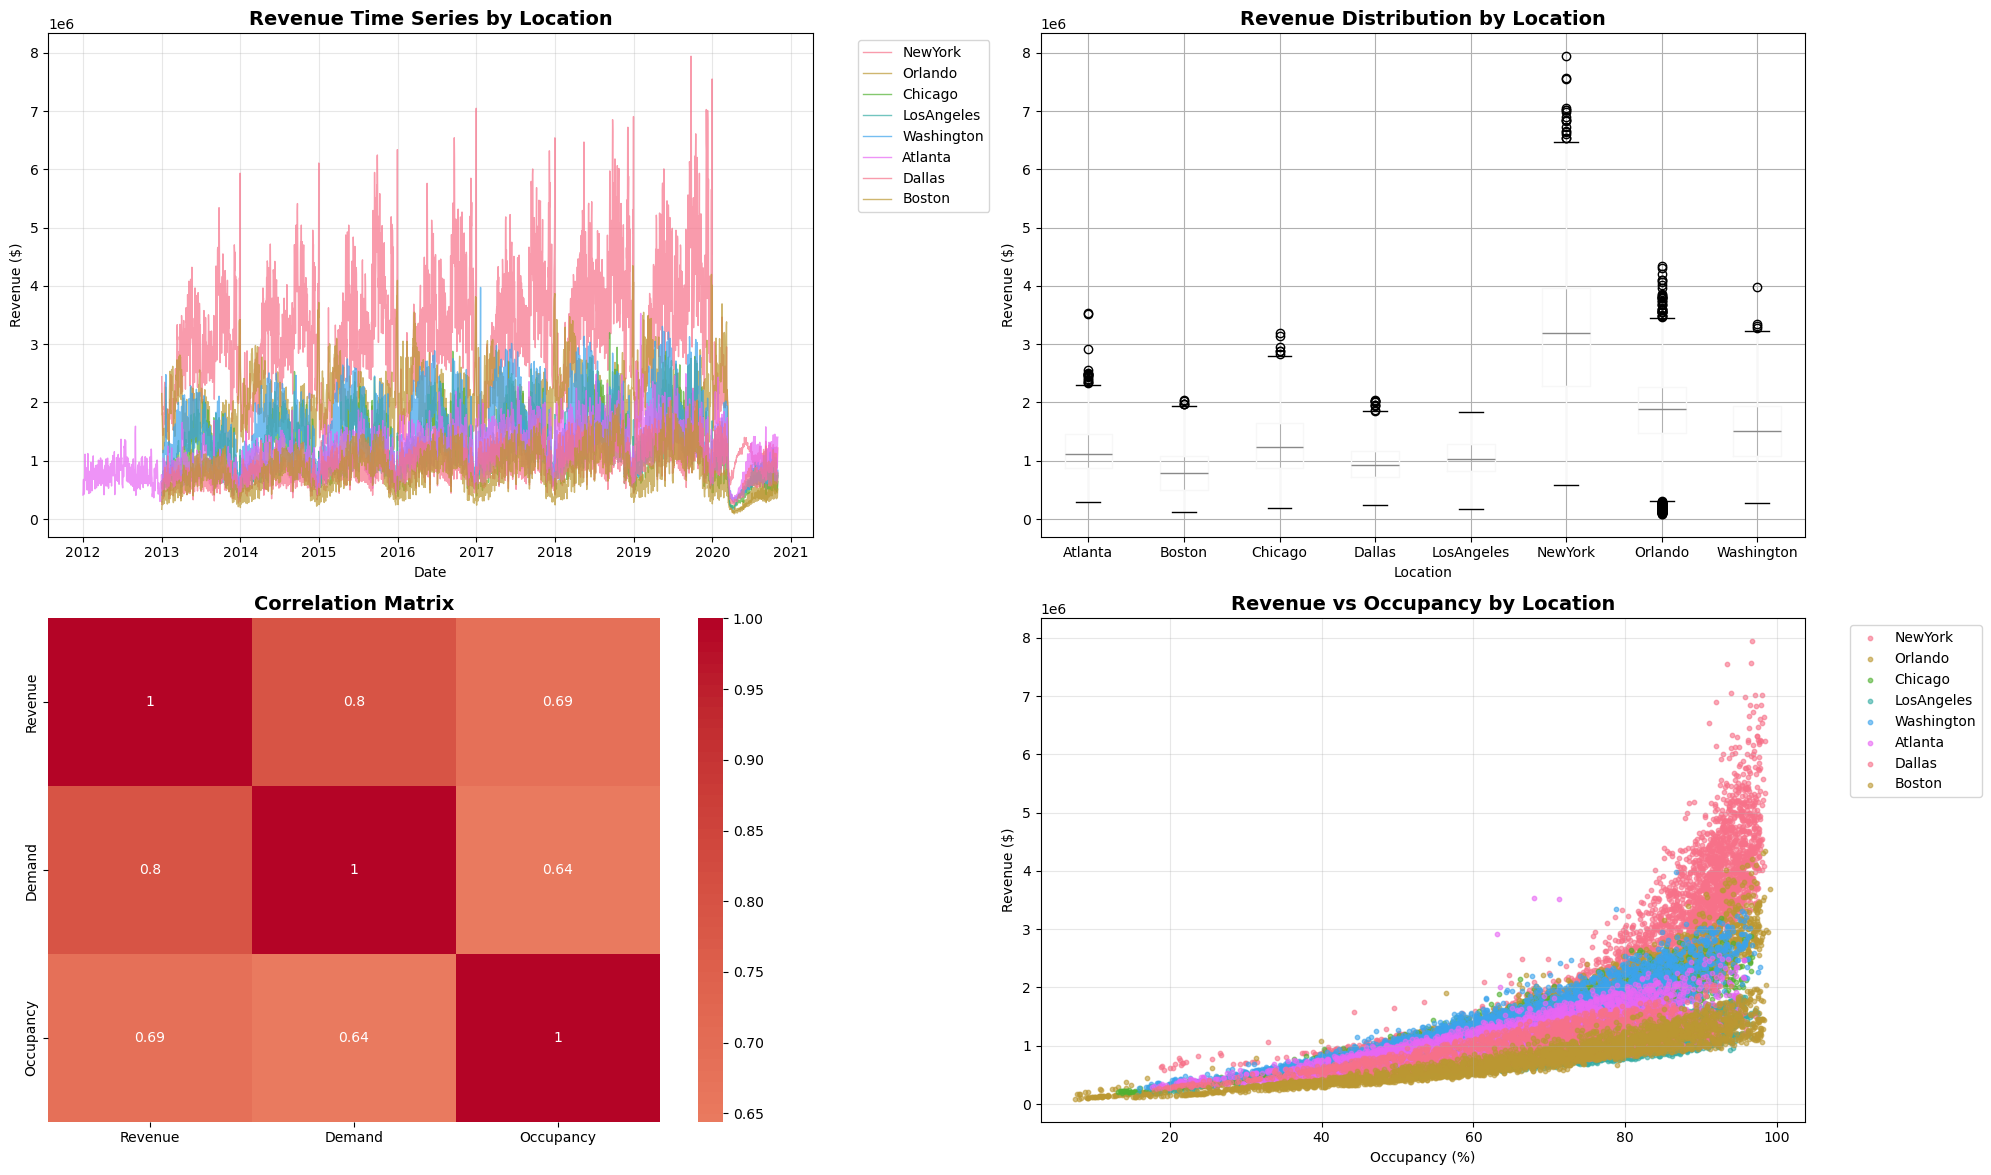

In [7]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1. Revenue time series by location
ax1 = axes[0, 0]
for location in df['Location'].unique():
    location_data = df[df['Location'] == location]
    ax1.plot(location_data.index, location_data['Revenue'], 
             label=location, alpha=0.7, linewidth=1)
ax1.set_title('Revenue Time Series by Location', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue ($)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Average revenue by location (box plot)
ax2 = axes[0, 1]
df.boxplot(column='Revenue', by='Location', ax=ax2)
ax2.set_title('Revenue Distribution by Location', fontsize=14, fontweight='bold')
ax2.set_xlabel('Location')
ax2.set_ylabel('Revenue ($)')
plt.suptitle('')  # Remove automatic title

# 3. Correlation matrix
ax3 = axes[1, 0]
# Select numeric columns for correlation
numeric_cols = ['Revenue', 'Demand', 'Occupancy']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax3)
ax3.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

# 4. Revenue vs Occupancy scatter plot
ax4 = axes[1, 1]
for location in df['Location'].unique():
    location_data = df[df['Location'] == location]
    ax4.scatter(location_data['Occupancy'], location_data['Revenue'], 
                label=location, alpha=0.6, s=10)
ax4.set_title('Revenue vs Occupancy by Location', fontsize=14, fontweight='bold')
ax4.set_xlabel('Occupancy (%)')
ax4.set_ylabel('Revenue ($)')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

we can see an important correlation between Demand, Occupancy and our target Revenue. We want to check if there is collinearity between features to avoid overfitting in the model

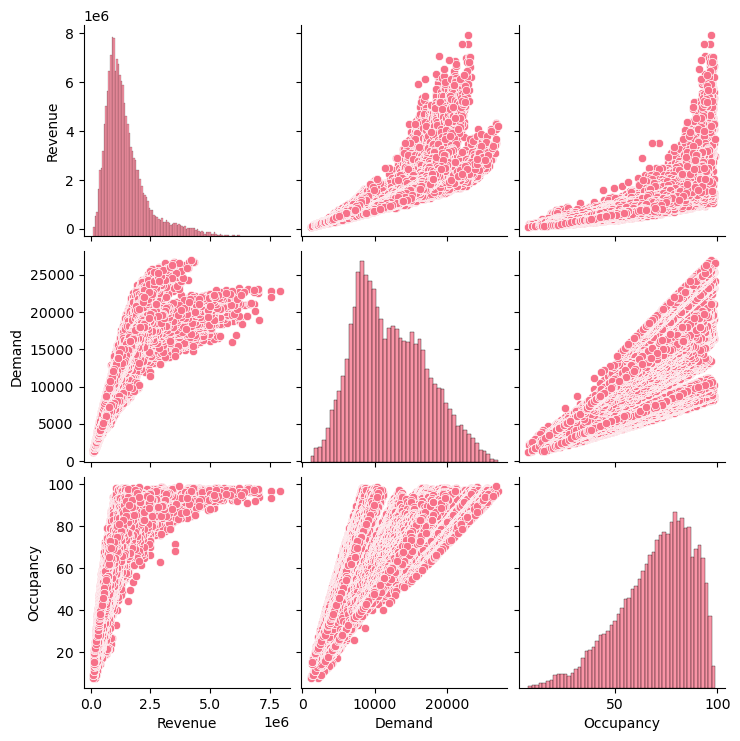

In [8]:
sns.pairplot(df[['Revenue', 'Demand', 'Occupancy']])
plt.show()

There is heavy correlation between features, we should consider removing some of them to avoid collinearity issues in the model training phase.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Esempio: solo alcune feature
X = df[['Revenue', 'Demand', 'Occupancy']].dropna()

# Aggiungi una costante per il calcolo del VIF
from statsmodels.tools.tools import add_constant
X_const = add_constant(X)

vif = pd.DataFrame()
vif["feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif #vif is 


,feature,VIF
0,const,20.075335
1,Revenue,3.173136
2,Demand,2.865540
3,Occupancy,1.990786


| feature    | VIF        | Action                                                   |
|------------|------------|----------------------------------------------------------|
| const      | 20.075335  | indicates high multicollinearity so we can ignore it    |
| Revenue    | 3.173136   | moderate multicollinearity so we can keep it            |
| Demand     | 2.865540   | moderate multicollinearity so we can keep it            |
| Occupancy  | 1.990786   | low multicollinearity so we can keep it                 |


### Handling COVID
Because there is an external event that breaks the equilibrium condition, we decided to discard the COVID period, oterwise we can try to model it like a change of state (pre and post covid)

In [10]:
df = df.sort_index()
df = df.loc[:'2019-12-31']

## 4. City Selection and Focus

Based on the analysis, let's select **Boston** as our focus city for forecasting due to:
1. Highest revenue levels among all cities
2. Strong seasonal patterns visible in the time series
3. Good data quality and range

In [11]:
# Filter for one city
CITY = "Boston"
df_boston = df[df['Location'] == CITY].copy()

# Use index (already DateTimeIndex)
df_boston.index = pd.to_datetime(df_boston.index)

# Restrict date range
df_boston
df_boston.head()


,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,Boston,166542.843005,1896.791481,22.856617
2013-01-02,Boston,245252.313124,2744.958462,33.077154
2013-01-03,Boston,289687.425946,3172.063926,38.223838
2013-01-04,Boston,297390.047491,3308.052694,39.862523
2013-01-05,Boston,291848.455941,3235.525351,38.988557


In [12]:
print(df_boston.index.min(), "→", df_boston.index.max())

#verify that the intervals are regualr (daily) 

print(df_boston.index.to_series().diff().value_counts())

2013-01-01 00:00:00 → 2019-12-31 00:00:00
Date
1 days    2555
Name: count, dtype: int64


The dataset contains 2555 days of data for Boston, which is sufficient for training robust forecasting models and as we can see they span ranges that avoid covid period.

In [13]:
from ipywidgets import interact, interactive, IntSlider, DatePicker

start_picker = DatePicker(
    description='Start date',
    value=df.index.min().date(),
    disabled=False
)
end_picker = DatePicker(
    description='End date',
    value=df.index.max().date(),
    disabled=False
)

@interact(start=start_picker, end=end_picker)
def plot_time_series(start, end):
    mask = (df_boston.index >= pd.to_datetime(start)) & (df_boston.index <= pd.to_datetime(end))
    plt.figure(figsize=(10, 4))
    plt.plot(df_boston.loc[mask].index, df_boston.loc[mask]['Revenue'], color='teal')
    plt.title(f"Hotel Revenue ({start} → {end})")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.grid(True, alpha=0.3)
    plt.show()


interactive(children=(DatePicker(value=datetime.date(2012, 1, 1), description='Start date', step=1), DatePicke…

because the line plot is a bit chaotic, let's analyse the timeserie in  a macro view

In [14]:
@interact(start=start_picker, end=end_picker)
def plot_rolling(start, end):
    mask = (df_boston.index >= pd.to_datetime(start)) & (df_boston.index <= pd.to_datetime(end))
    subset = df_boston.loc[mask]

    plt.figure(figsize=(12,6))
    plt.plot(subset['Revenue'].rolling(7, center=True).mean(), 
             label='Rolling 7-day', alpha=0.8, color='teal')
    plt.plot(subset['Revenue'].rolling(30, center=True).mean(), 
             label='Rolling 30-day (≈ monthly)', alpha=0.8, color='orange')
    plt.plot(subset['Revenue'].rolling(365, center=True).mean(), 
             label='Rolling 365-day (yearly)', alpha=0.9, color='crimson')

    plt.title(f'Hotel Revenue – Rolling Averages ({start} → {end})')
    plt.xlabel('Date')
    plt.ylabel('Revenue (smoothed)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(DatePicker(value=datetime.date(2012, 1, 1), description='Start date', step=1), DatePicke…

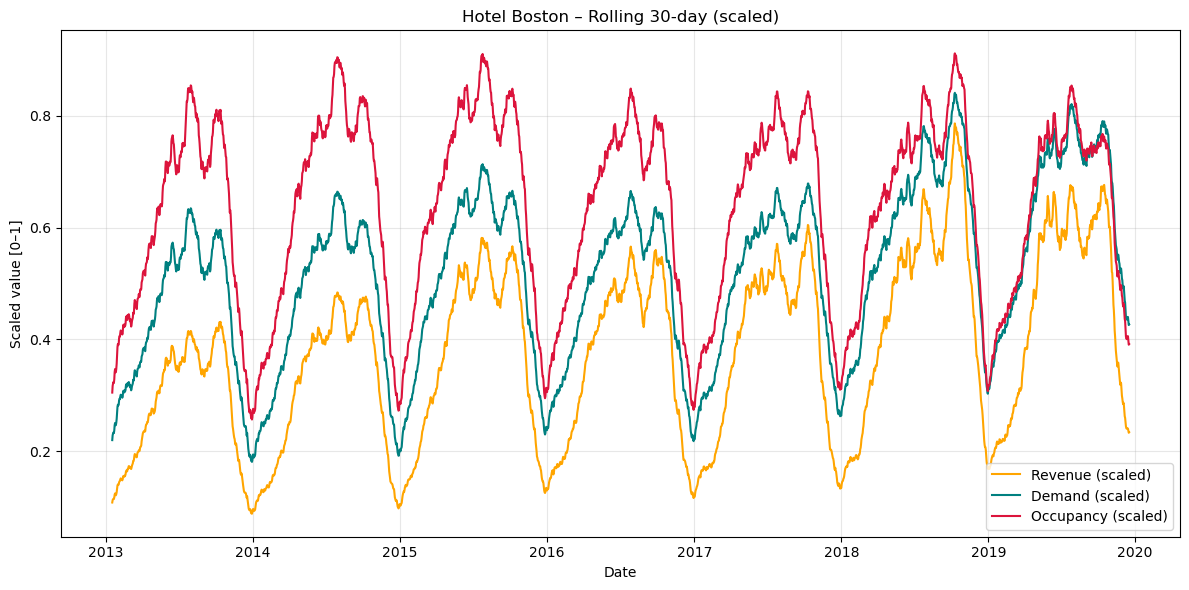

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_boston[['Revenue', 'Demand', 'Occupancy']])
scaled_df = pd.DataFrame(scaled, index=df_boston.index, columns=['Revenue', 'Demand', 'Occupancy'])

plt.figure(figsize=(12,6))
plt.plot(scaled_df['Revenue'].rolling(30, center=True).mean(), label='Revenue (scaled)', color='orange')
plt.plot(scaled_df['Demand'].rolling(30, center=True).mean(), label='Demand (scaled)', color='teal')
plt.plot(scaled_df['Occupancy'].rolling(30, center=True).mean(), label='Occupancy (scaled)', color='crimson')

plt.title('Hotel Boston – Rolling 30-day (scaled)')
plt.xlabel('Date')
plt.ylabel('Scaled value [0–1]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


As we can see from the rolling 30 day shows clear seasonal patterns with peaks during summer and troughs in winter, which is typical for the hotel industry.

In [16]:
@interact(metric=['Revenue', 'Demand', 'Occupancy'])
def plot_seasonal(metric):
    df_boston['Month'] = df_boston.index.month_name().str.slice(stop=3)
    df_boston['Year'] = df_boston.index.year
    monthly = df_boston.groupby(['Year', 'Month'])[metric].mean().reset_index()
    
    # Ordine corretto dei mesi
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly['Month'] = pd.Categorical(monthly['Month'], categories=month_order, ordered=True)
    
    plt.figure(figsize=(12,6))
    sns.lineplot(data=monthly, x='Month', y=metric, hue='Year', palette='coolwarm')
    plt.title(f'Seasonal Plot – Monthly {metric} by Year')
    plt.xlabel('Month')
    plt.ylabel(metric)
    plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='metric', options=('Revenue', 'Demand', 'Occupancy'), value='Revenu…

Usually the revenues are higher in the warmer month

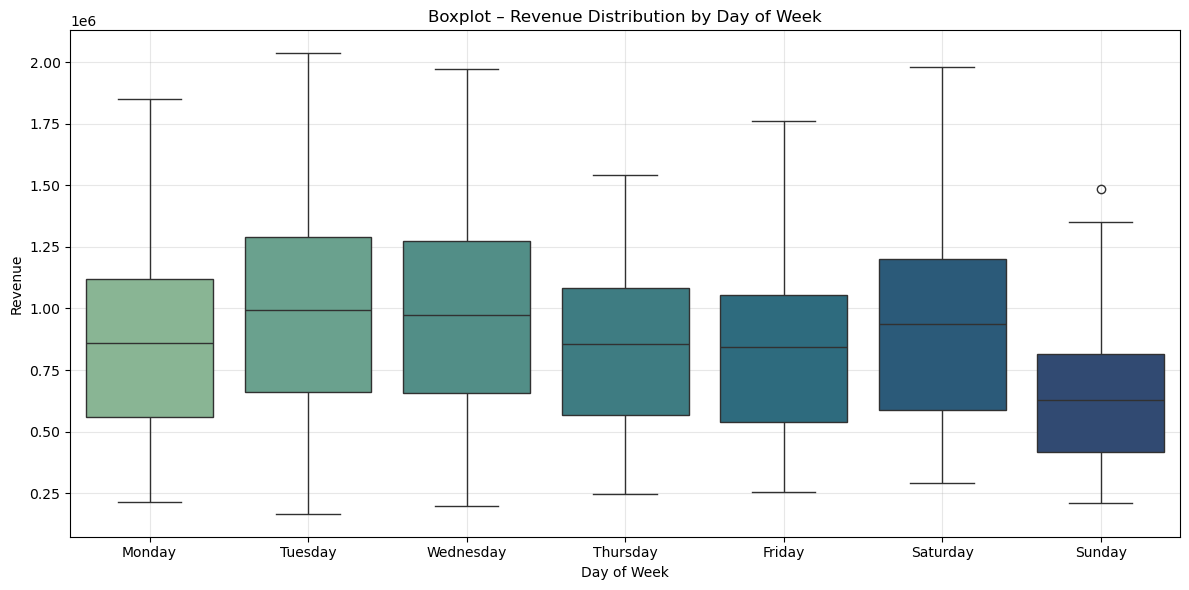

In [17]:
df_boston['DayOfWeek'] = df_boston.index.day_name()
df_boston['DayOfWeek'] = pd.Categorical(df_boston['DayOfWeek'], categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)
plt.figure(figsize=(12,6))
sns.boxplot(data=df_boston, x='DayOfWeek', y='Revenue', palette='crest')
plt.title('Boxplot – Revenue Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The day of the week shows weekly seasonality with Sunday the day with the lowest revenue

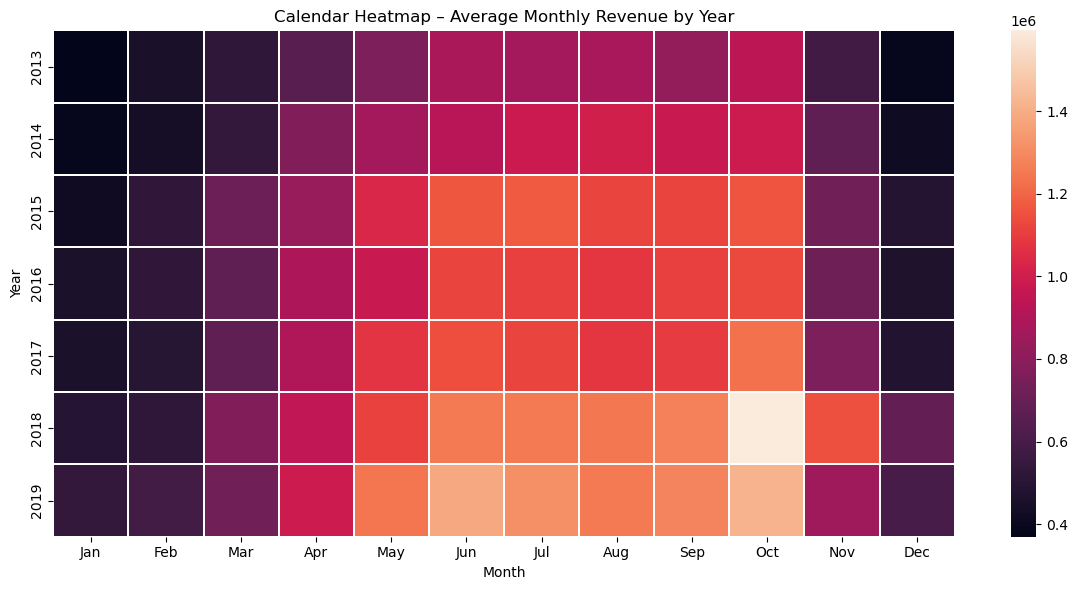

In [18]:
pivot2 = df_boston.pivot_table(values='Revenue',
                               index='Year',
                               columns='Month',
                               aggfunc='mean')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot2 = pivot2[month_order]

plt.figure(figsize=(12,6))
sns.heatmap(pivot2, linewidths=0.3, annot=False)
plt.title('Calendar Heatmap – Average Monthly Revenue by Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

Again we can see the seasonality patterns with higher revenues in summer months and lower in winter ones. with an unusual peak in October 2018 probably due to a special event in the city.

## 4b. Correlation between features for Boston

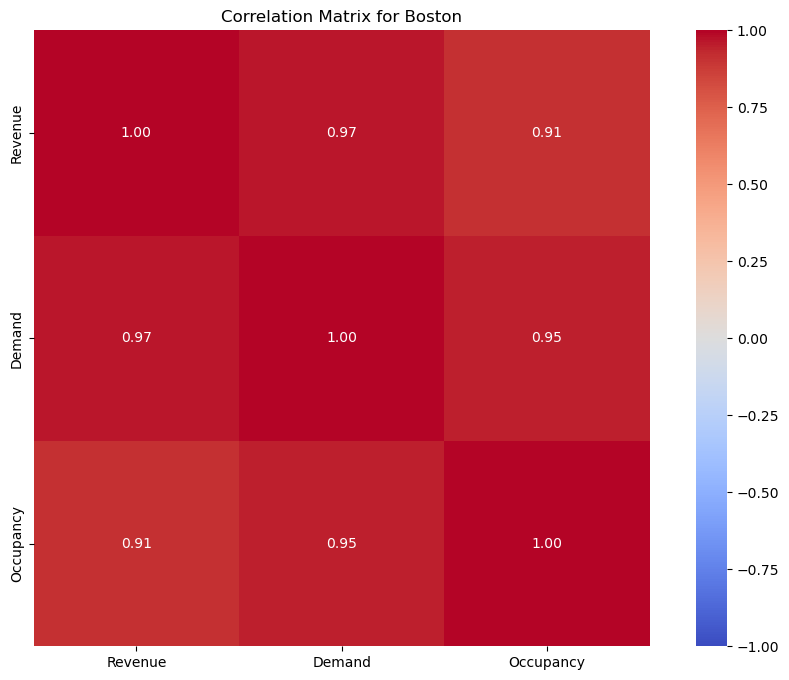

In [19]:
# Correlation Analysis
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(df, title='Correlation Matrix'):
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, vmin=-1, vmax=1)
    plt.title(title)
    plt.show()

plot_correlation_matrix(df_boston[['Revenue', 'Demand', 'Occupancy']], title=f'Correlation Matrix for {CITY}')

Occupancy and Demand show a strong positive correlation with Revenue, indicating that higher occupancy rates and demand levels are associated with increased revenue. This suggests that these variables are important predictors for forecasting revenue in the hotel industry but using them directly may introduce multicollinearity issues in some models as mentioned earlier.
But in our case we will use them as exogenous variables in our models so it should be fine.

Given the strong correlations observed, we could use both either only Demand or only Occupancy as exogenous variables in our forecasting models to predict Revenue. However, using both variables may provide complementary information that could enhance the model's predictive performance.

**Models that can incorporate multiple exogenous variables, such as SARIMAX or LSTM, would be suitable choices for this forecasting task.**

---

## 5. Decomposition

because we don't have missing values and we have high-frequency data (daily) that can exhibit multiple seasonal patterns we can use an extension of STL decomposition for mulitple seasonality known as **MSTL** using LOESS.
To refresh, MSTL decomposes a time series into trend, seasonal, and remainder components, allowing us to analyze each aspect separately. Differently from STL, MSTL can handle multiple seasonal patterns, making it suitable for complex time series data.

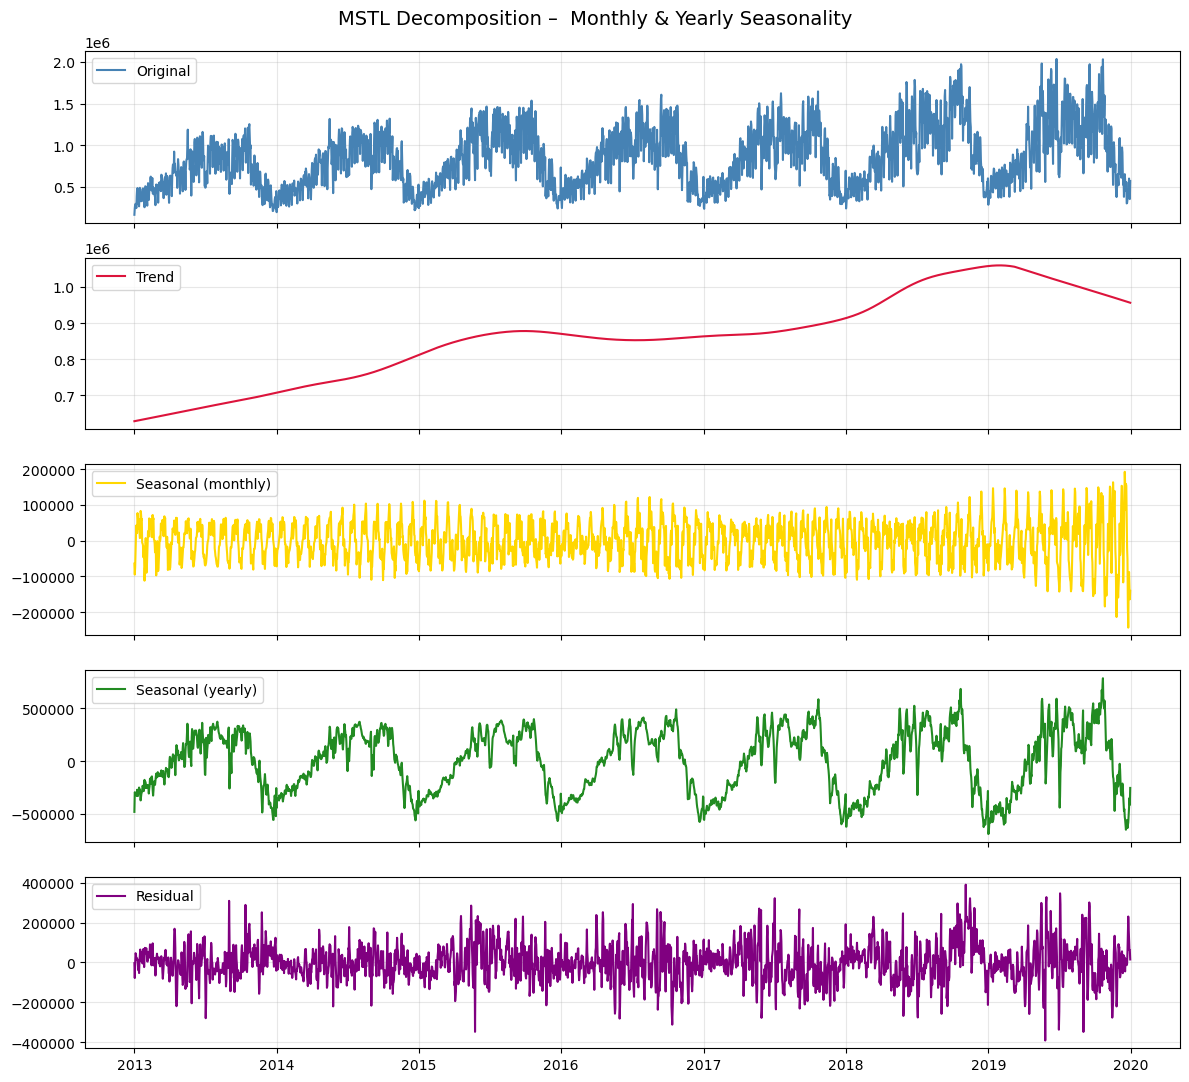

In [20]:
from statsmodels.tsa.seasonal import MSTL
y = df_boston['Revenue'].asfreq('D')
mstl = MSTL(y, periods=(7, 30, 365))
res = mstl.fit()

trend = res.trend
seasonal_month = res.seasonal['seasonal_30']
seasonal_year = res.seasonal['seasonal_365']
resid = res.resid

# Plot
fig, axs = plt.subplots(5, 1, figsize=(12, 11), sharex=True)
axs[0].plot(y, color='steelblue', label='Original')
axs[1].plot(trend, color='crimson', label='Trend')
axs[2].plot(seasonal_month, color='gold', label='Seasonal (monthly)')
axs[3].plot(seasonal_year, color='forestgreen', label='Seasonal (yearly)')
axs[4].plot(resid, color='purple', label='Residual')

for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('MSTL Decomposition –  Monthly & Yearly Seasonality', fontsize=14)
plt.tight_layout()
plt.show()

## Frequency Domain Analysis (FFT)

In [21]:
from scipy.fft import fft, fftfreq
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

# Create figure with 3 subplots
fig = make_subplots(rows=3, cols=1, subplot_titles=("Revenue FFT Spectrum", "Demand FFT Spectrum", "Occupancy FFT Spectrum"),
                    vertical_spacing=0.1)

# Function to compute and plot FFT
def plot_fft(data, column, row, color, n_top_periods=10):
    # Get the values and compute FFT
    y = data[column].values
    N = len(y)
    
    # Compute sample spacing (assuming daily data)
    time_diff = pd.Series(data.index).diff().median().total_seconds()
    T = time_diff / (24 * 3600)  # Convert to days
    
    # Compute FFT
    yf = fft(y)
    xf = fftfreq(N, T)[:N//2]
    magnitudes = 2.0/N * np.abs(yf[:N//2])
    
    # Skip the DC component (0 frequency) and filter frequencies above 0.002
    mask = (xf >= 0.002) & (xf > 0)
    xf_filtered = xf[mask]
    magnitudes_filtered = magnitudes[mask]
    
    # Plot only the filtered frequencies
    fig.add_trace(
        go.Scatter(x=xf_filtered, y=magnitudes_filtered, 
                  mode='lines', name=column, line=dict(color=color)),
        row=row, col=1
    )
    
    # Find top n periods based on magnitude
    top_periods = []
    if len(magnitudes_filtered) > 0:
        # Get indices of top n peaks from the filtered data
        peaks = np.argsort(magnitudes_filtered)[-n_top_periods:]  # Get indices of top peaks
        
        for peak_idx in peaks:
            freq = xf_filtered[peak_idx]
            log_x_adj = np.log10(freq)
            magnitude = magnitudes_filtered[peak_idx]
            period = 1/freq
            
            # Add to list of top periods
            top_periods.append({
                'period': period,
                'frequency': freq,
                'magnitude': magnitude
            })
            
            # Add annotation to plot
            fig.add_annotation(
                x=log_x_adj, y=magnitude,
                text=f"{period:.1f} days",
                showarrow=True, arrowhead=1,
                row=row, col=1
            )
            
    # Sort periods by magnitude (highest first)
    top_periods.sort(key=lambda x: x['magnitude'], reverse=False)
    
    return top_periods

# Plot FFT for each column
peaks_revenue = plot_fft(df_boston, 'Revenue', 1, 'blue')
peaks_demand = plot_fft(scaled_df, 'Demand', 2, 'green')
peaks_occupancy = plot_fft(scaled_df, 'Occupancy', 3, 'red')

# Update layout
fig.update_layout(
    title_text=f"FFT Spectrum Analysis",
    height=900,
    showlegend=False
)

# Update x and y axis labels, and set x-axis to log scale
for i in range(1, 4):
    fig.update_xaxes(title_text="Frequency (1/day)", type="log", row=i, col=1)
    fig.update_yaxes(title_text="Magnitude", row=i, col=1)

fig.show()

### 5b. Forecasting indicators - trend and seasonal strength

let's start with a first forecasting indicator, after the decomposition we expect that the timeseries has a strong trend and seasonality

In [22]:
trend_strength = max(0, 1 - np.var(res.resid) / np.var(res.trend + res.resid))
seasonal_strength = max(0, 1 - np.var(res.resid) / np.var(res.seasonal.sum(axis=1) + res.resid))

print(f"Trend strength: {trend_strength:.3f}")
print(f"Seasonality strength: {seasonal_strength:.3f}")

Trend strength: 0.638
Seasonality strength: 0.925


63.8% of the variance in the timeseries is given by the trend meaning that it is not completely stationary but shows a strong trend and 92.5% of the variance  is given by the seasonality, meaning that it's strong seasonal, near periodic. Models that use explicit seasonality will be very powerful

In [23]:
import antropy as ant
from typing import Dict, Union, Optional
from scipy import signal
from statsmodels.tsa.stattools import acf
import nolds
import ordpy

def variance_ratio(x: np.ndarray) -> Optional[float]:
    x = np.asarray(x, float)
    if x.size < 3:
        return np.nan
    num = np.nanvar(np.diff(x))
    den = np.nanvar(x)
    return float(num / den) if den > 0 else np.nan

def spectral_measures(x: np.ndarray) -> Dict[str, float]:
    x = np.asarray(x, float)
    if x.size < 16:
        return dict(spectral_entropy=np.nan, spectral_forecastability=np.nan, periodicity_index=np.nan)
    try:
        Hs = ant.spectral_entropy(x, sf=1.0, method='welch', normalize=True)
    except Exception:
        Hs = np.nan
    Omega = np.nan if np.isnan(Hs) else 1.0 - Hs
    try:
        freqs, psd = signal.periodogram(x, detrend='linear', scaling='density')
        if psd.size > 1:
            peak = np.nanmax(psd[1:])
            total = np.nansum(psd[1:])
            per_idx = (peak / total) if total and total > 0 else np.nan
        else:
            per_idx = np.nan
    except Exception:
        per_idx = np.nan
    return dict(spectral_entropy=Hs, spectral_forecastability=Omega, periodicity_index=per_idx)

def svd_entropy_safe(x: np.ndarray, order: int = 3, delay: int = 1) -> float:
    if x.size < order * delay + 1:
        return np.nan
    try:
        return ant.svd_entropy(x, order=order, delay=delay, normalize=True)
    except Exception:
        return np.nan

def perm_entropy_safe(x: np.ndarray, order: int = 5, delay: int = 1) -> float:
    if x.size < order * delay + 1:
        return np.nan
    try:
        return ant.perm_entropy(x, order=order, delay=delay, normalize=True)
    except Exception:
        return np.nan

def sample_entropy_safe(x: np.ndarray, m: int = 2, r_fraction: float = 0.2) -> float:
    x = np.asarray(x, float)
    if x.size < 20:
        return np.nan
    s = np.nanstd(x)
    if s == 0:
        return np.nan
    for rf in (r_fraction, 0.25, 0.15, 0.3):
        try:
            val = ant.sample_entropy(x, order=m)
            if np.isfinite(val):
                return float(val)
        except Exception as e:
            pass
    return np.nan

def approximate_entropy_safe(x: np.ndarray, m: int = 2, r_fraction: float = 0.2) -> float:
    x = np.asarray(x, float)
    if x.size < 20:
        return np.nan
    s = np.nanstd(x)
    if s == 0:
        return np.nan
    for rf in (r_fraction, 0.25, 0.15, 0.3):
        try:
            val = ant.app_entropy(x, order=m)
            if np.isfinite(val):
                return float(val)
        except Exception:
            pass
    return np.nan

def quantize_series(x: np.ndarray, n_bins: int = 8) -> np.ndarray:
    x = np.asarray(x, float)
    if np.unique(x).size <= 1:
        return np.zeros_like(x, dtype=int)
    try:
        q = pd.qcut(x, q=min(n_bins, max(2, np.unique(x).size)), labels=False, duplicates='drop')
        return q.astype(int).to_numpy()
    except Exception:
        bins = np.linspace(np.nanmin(x), np.nanmax(x), n_bins + 1)
        return np.digitize(x, bins[:-1], right=False).astype(int)

def lzc_safe(x: np.ndarray, n_bins: int = 8) -> float:
    if x.size < 16:
        return np.nan
    try:
        sym = quantize_series(x, n_bins=n_bins)
        return ant.lziv_complexity(sym, normalize=True)
    except Exception:
        return np.nan

def ordpy_complexity_entropy(x: np.ndarray, dx: int = 5, tau: int = 1) -> Dict[str, float]:
    x = np.asarray(x, float)
    if x.size < dx * tau + 1:
        return dict(ordpy_perm_entropy=np.nan, ordpy_stat_complexity=np.nan)
    try:
        # Newer ordpy API
        H, C = ordpy.complexity_entropy(x, dx=dx, dy=1, taux=tau, tauy=1, probs=False)
    except Exception as e:
        print(f"ordpy error: {e}")
        # Older ordpy API fallback
        H, C = ordpy.complexity_entropy(x, dx=dx, taux=tau)
    return dict(ordpy_perm_entropy=float(H), ordpy_stat_complexity=float(C))

def acf_measures(x: np.ndarray, max_lag: int = 52) -> Dict[str, float]:
    if x.size < max_lag + 2:
        return dict(acf1=np.nan, acf_mean_abs=np.nan)
    try:
        a = acf(x, nlags=max_lag, fft=True, missing='drop')
        a1 = float(a[1]) if a.size > 1 else np.nan
        asum = float(np.nanmean(np.abs(a[1:])))
        return dict(acf1=a1, acf_mean_abs=asum)
    except Exception:
        return dict(acf1=np.nan, acf_mean_abs=np.nan)

def dfa_alpha_safe(x: np.ndarray) -> float:
    if x.size < 64:
        return np.nan
    try:
        return float(nolds.dfa(x))
    except Exception:
        return np.nan

def ordinal_entropy(x: np.ndarray) -> Dict[str, float]:
    return ordpy_complexity_entropy(x, dx=5, tau=1)

#TypeError: 'float' object is not iterable 
# check the timeseries forecastability indicators
features = {}
series = df_boston['Revenue'].values

# Compute various forecastability indicators
features = {}
series = df_boston['Revenue'].values

features['variance_ratio'] = variance_ratio(series)
features['dfa_alpha'] = dfa_alpha_safe(series)
features.update(spectral_measures(series))
features.update(ordinal_entropy(series))
features.update(acf_measures(series))

print("Forecastability indicators:")
for key, value in features.items():
    print(f"{key}: {round(value, 4)}")


Forecastability indicators:
variance_ratio: 0.3202
dfa_alpha: 1.0978
spectral_entropy: 0.5821
spectral_forecastability: 0.4179
periodicity_index: 0.5302
ordpy_perm_entropy: 0.8707
ordpy_stat_complexity: 0.2012
acf1: 0.8391
acf_mean_abs: 0.5668



The following table summarizes the computed forecastability indicators for the Boston Revenue time series, along with their values and interpretations:

| Indicator              | Value   | Interpretation |
|------------------------|---------|----------------|
| **variance_ratio**     | 0.3202 | Low value indicates trend presence (0 to 1 scale) |
| **dfa_alpha**          | 1.0979 | High value indicates long-range dependence (0 to ∞ scale) |
| **spectral_entropy**   | 0.5821 | Moderate value indicates some predictability (0 to 1 scale) |
| **spectral_forecastability** | 0.4179 | Low value indicates limited forecastability (0 to 1 scale) |
| **periodicity_index**  | 0.5308 | Moderate value indicates some periodicity (0 to 1 scale) |
| **ordpy_perm_entropy** | 0.8706 | High value indicates complex dynamics (0 to 1 scale) |
| **ordpy_stat_complexity** | 0.2013 | Low value indicates simple dynamics (0 to 1 scale) |
| **acf1**               | 0.8387 | High value indicates strong autocorrelation (0 to 1 scale) |
| **acf_mean_abs**       | 0.5666 | Moderate value indicates some autocorrelation (0 to 1 scale) |

**Overall Summary:**  
Looking at the forecastability indicators, the Revenue time series exhibits characteristics such as trend presence, long-range dependence, and strong autocorrelation. However, it also shows limited forecastability and complex dynamics, suggesting that while there are patterns to exploit, the series may be challenging to predict accurately.

## 6. Stationarity Check (ADF)

In [24]:
def test_adf(series, title=""):
    result = adfuller(series.dropna())
    print(f"ADF test for {title}:")
    print("  Test statistic:", result[0])
    print("  p-value:", result[1])
    print("  # lags used:", result[2])
    print("  # observations:", result[3])
    for key, val in result[4].items():
        print(f"    critical {key}:", val)
    print()
    
test_adf(df_boston['Revenue'], title="Revenue")

ADF test for Revenue:
  Test statistic: -3.123000632238409
  p-value: 0.024897204337802143
  # lags used: 27
  # observations: 2528
    critical 1%: -3.432939379929173
    critical 5%: -2.862683979868293
    critical 10%: -2.5673789838429837




### ADF Test Results for Revenue

- **Test Statistic**: -3.1230  
  *Interpretation*: The test statistic is less than the critical value at the 5% significance level, indicating stationarity.

- **p-value**: 0.0249  
  *Interpretation*: The p-value is less than 0.05, allowing us to reject the null hypothesis of non-stationarity.

- **Lags Used**: 27  
  *Interpretation*: The number of lags used in the test.

- **Observations**: 2528  
  *Interpretation*: The number of observations used in the test.

- **Critical Values**:  
  - 1%: -3.4329  
  - 5%: -2.8627  
  - 10%: -2.5674  

*Conclusion*: The time series is stationary at the 5% significance level that means we can use models that assume stationarity without differencing.

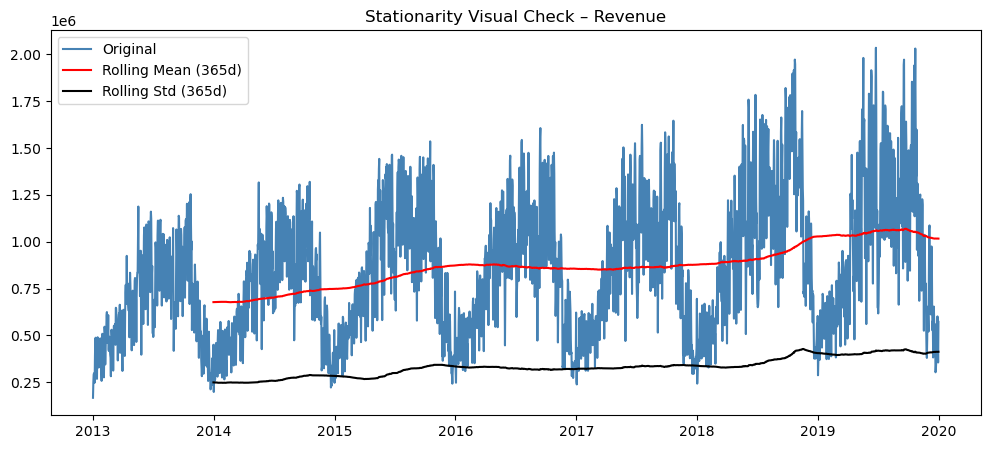

In [25]:
rolling_mean = y.rolling(window=365).mean()
rolling_std = y.rolling(window=365).std()

plt.figure(figsize=(12,5))
plt.plot(y, color='steelblue', label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean (365d)')
plt.plot(rolling_std, color='black', label='Rolling Std (365d)')
plt.legend()
plt.title('Stationarity Visual Check – Revenue')
plt.show()

because our p-value < 0.5, we can reject the $H_0$ and for this reason our timeseries is stationary. Also the test statistic is less than the critical value, confirming the stationarity 

## 7. Autocorrelation Analysis (ACF) and Partial Autocorrelation (PACF)

first we perform the ACF to see the timeseries correlation with itself at different lags

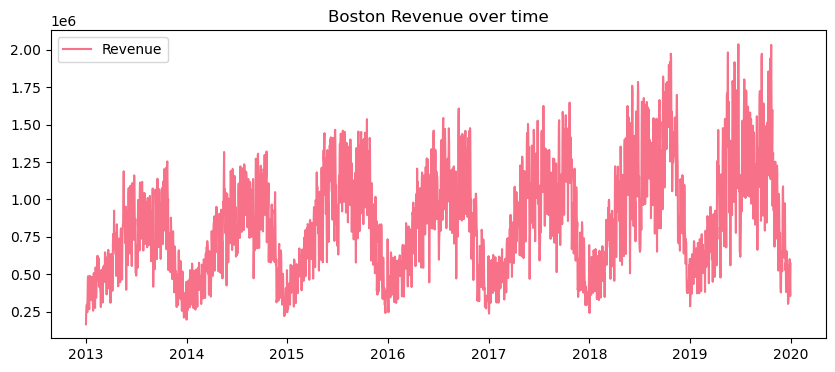

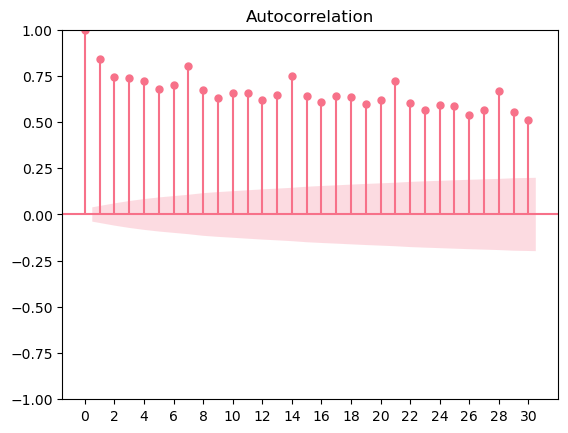

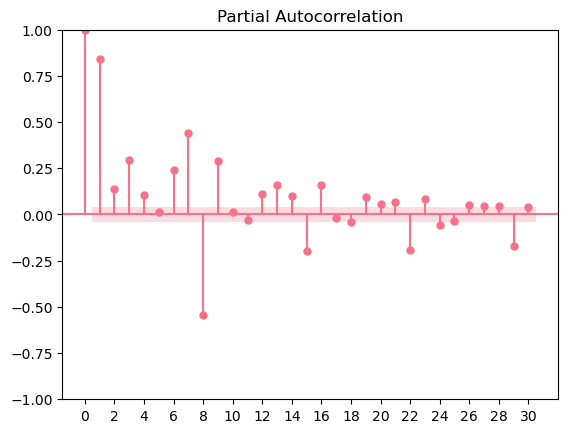

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller



# Plot revenue over time
plt.figure(figsize=(10,4))
plt.plot(df_boston['Revenue'], label="Revenue")
plt.title(f"{CITY} Revenue over time")
plt.legend()
plt.show()

plot_acf(df_boston['Revenue'].dropna(), lags=30)
plt.xticks(ticks=np.arange(0, 31, 2))
plt.show()
plot_pacf(df_boston['Revenue'].dropna(), lags=30)
plt.xticks(ticks=np.arange(0, 31, 2))
plt.show()





- The ACF plot shows clear peaks of autocorrelation every 7 days, indicating strong weekly seasonality in the Revenue data.
- The PACF plot reveals:
  - A moderate positive partial autocorrelation at lag 7 (approximately 0.5).
  - A significant negative partial autocorrelation at lag 8 (approximately -0.5).

These patterns suggest that the time series exhibits weekly cycles, with potential influences from the previous week's values and a negative adjustment at lag 8.

## 8. Outlier Detection

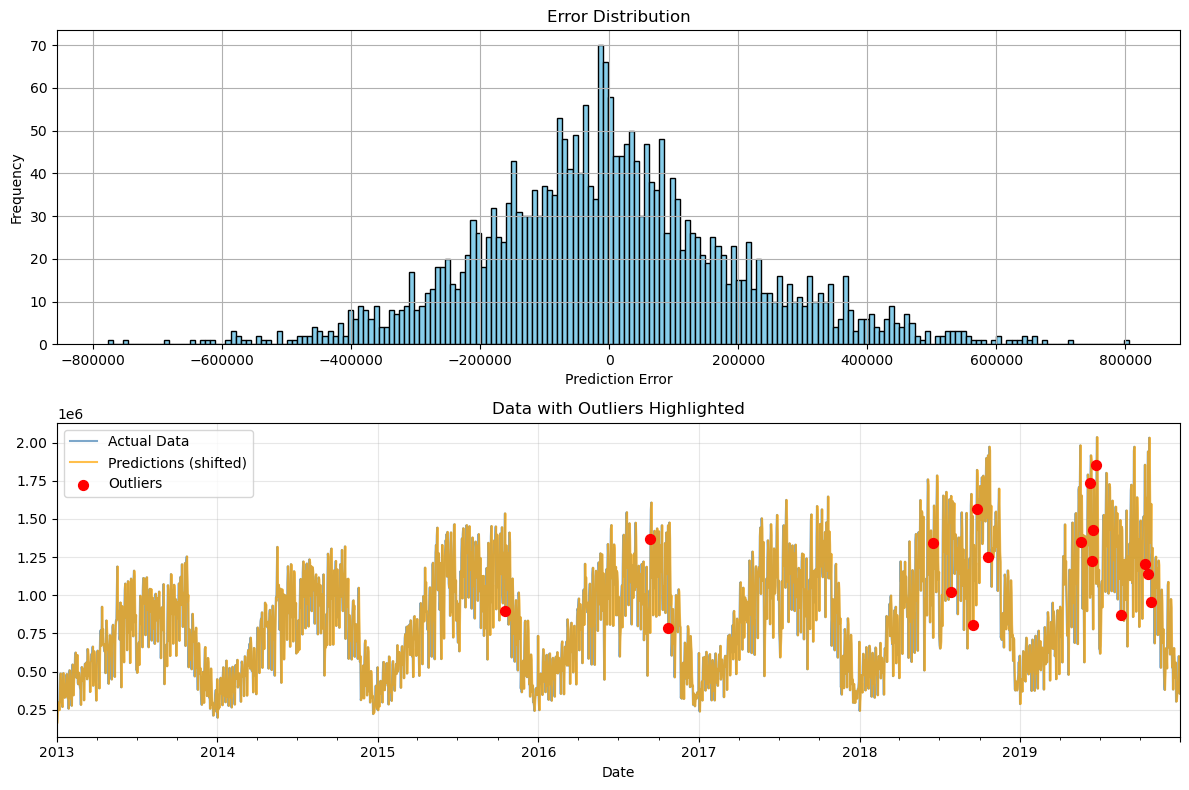

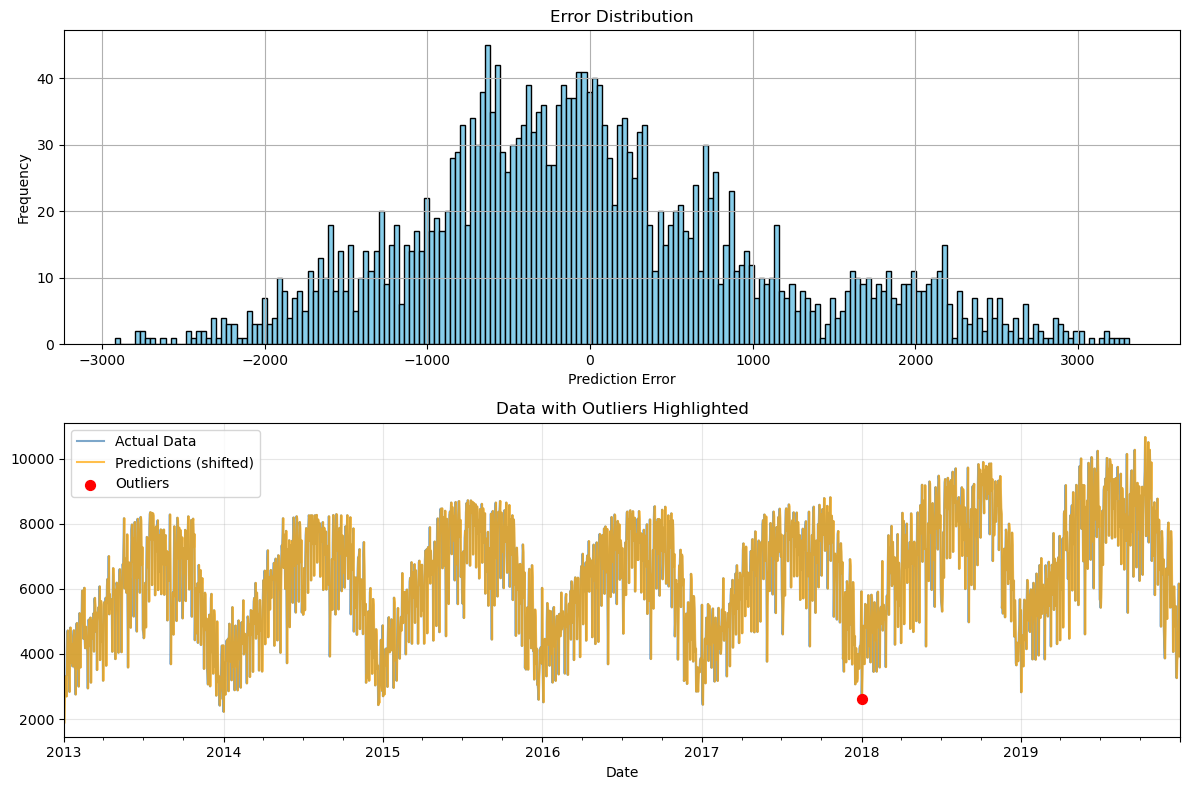

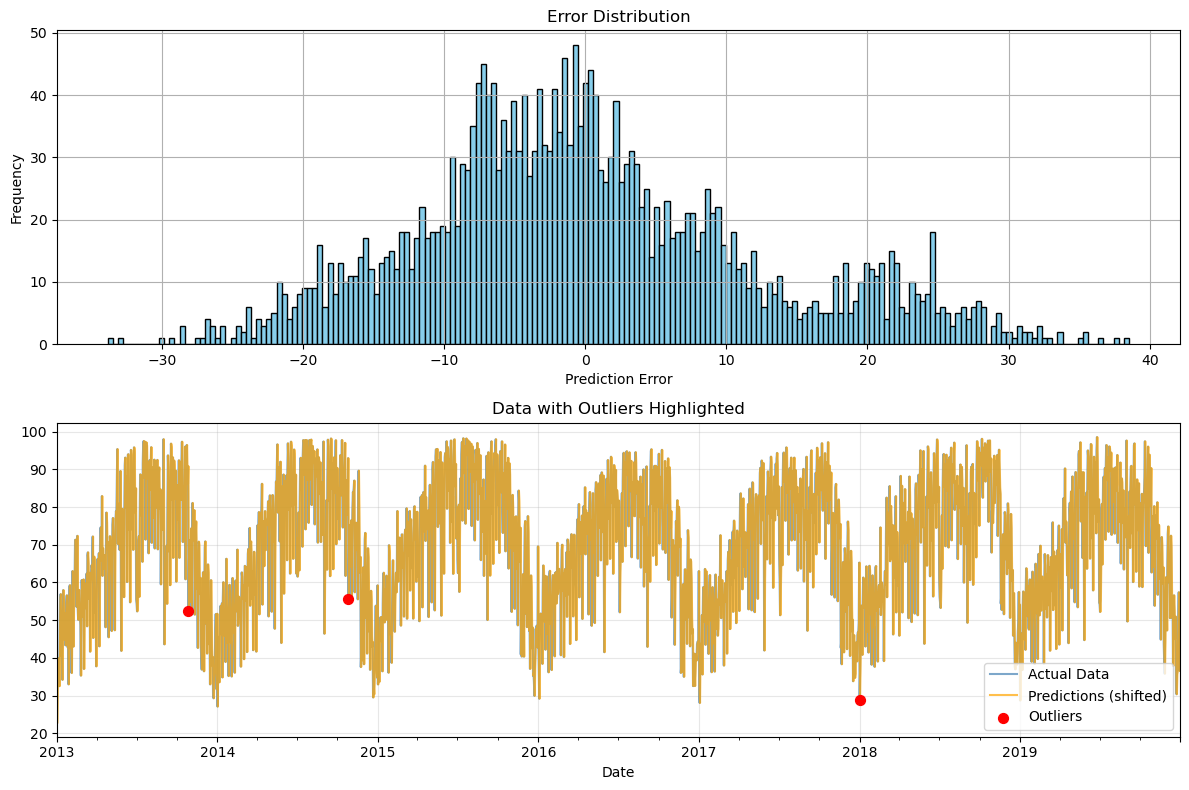

array([ 299,  663, 1826])

In [27]:
def outlier_detector(df, n_sigma=3.):
    preds = df.shift(1)

    # Calculate prediction error and standard deviation
    err = preds - df
    sigma = err.std()
    candidates = np.argwhere((err.abs() > sigma * n_sigma).values).ravel()

    # Filter consecutive outliers to keep only the first
    is_outlier = []
    for i, c in enumerate(candidates):
        if i == 0 or candidates[i - 1] != c - 1:
            is_outlier.append(c)
    is_outlier = np.array(is_outlier)

    # Plot error distribution
    fig, ax = plt.subplots(2, 1, figsize=(12, 8))
    err.hist(bins=200, ax=ax[0], color='skyblue', edgecolor='black')
    ax[0].set_title('Error Distribution')
    ax[0].set_xlabel('Prediction Error')
    ax[0].set_ylabel('Frequency')

    # Plot actual data with outliers highlighted
    df.plot(ax=ax[1], label='Actual Data', alpha=0.7, color='steelblue')
    preds.plot(ax=ax[1], label='Predictions (shifted)', alpha=0.7, color='orange')
    if len(is_outlier) > 0:
        ax[1].scatter(df.index[is_outlier], df.iloc[is_outlier].values, 
                      color='red', label='Outliers', zorder=5, s=50)
    ax[1].set_title('Data with Outliers Highlighted')
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return is_outlier

# Example usage
outlier_detector(df_boston['Revenue'])
outlier_detector(df_boston['Demand'])
outlier_detector(df_boston['Occupancy'])

Outliers in the Revenue, Demand and Occupancy time series are not many and do not seem to affect the overall trend and seasonality of the data. Therefore, we decide to keep them as they are, as they may represent real-world events that could be important for forecasting.

---

# Adjusting for inflation
In this section we try to adjust the Revenue time series for inflation to ensure that our forecasts reflect real purchasing power over time but also to **mitigate the long-term effects of inflation**. The impact might not be very significant given the relatively short time span of the data (7 years), but it is still a good practice to account for inflation in financial time series analysis.

In [28]:
import pandas as pd
import numpy as np

def adjust_for_inflation(df, revenue_column='Revenue', cpi_series=None, base_year=2013):
    if cpi_series is None:
        raise ValueError("CPI series must be provided. You can obtain CPI data from sources like FRED or BLS.")
    
    # Create a copy of the DataFrame
    df_adjusted = df.copy()
    
    # Get CPI for base year
    base_cpi_value = cpi_series.get(base_year)
    if base_cpi_value is None:
        raise ValueError(f"CPI data for base year {base_year} not found")
    
    # Map yearly CPI values to each date in the DataFrame
    cpi_mapped = df_adjusted.index.year.map(cpi_series)
    
    # Calculate inflation-adjusted revenue
    df_adjusted[f'{revenue_column}_real'] = df_adjusted[revenue_column] * (base_cpi_value / cpi_mapped)
    
    return df_adjusted

In [29]:
import pandas as pd
import numpy as np

cpi_annual = {
    2013: 232.96,
    2014: 236.74,
    2015: 237.02,
    2016: 240.01,
    2017: 245.12,
    2018: 251.11,
    2019: 255.66,
    2020: 258.81
}

# Now apply the inflation adjustment function with the annual CPI
df_boston_adjusted = adjust_for_inflation(df_boston, cpi_series=cpi_annual)

# Display the first few rows of the adjusted DataFrame
print(df_boston_adjusted.head())

           Location        Revenue       Demand  Occupancy Month  Year  \
Date                                                                     
2013-01-01   Boston  166542.843005  1896.791481  22.856617   Jan  2013   
2013-01-02   Boston  245252.313124  2744.958462  33.077154   Jan  2013   
2013-01-03   Boston  289687.425946  3172.063926  38.223838   Jan  2013   
2013-01-04   Boston  297390.047491  3308.052694  39.862523   Jan  2013   
2013-01-05   Boston  291848.455941  3235.525351  38.988557   Jan  2013   

            DayOfWeek   Revenue_real  
Date                                  
2013-01-01    Tuesday  166542.843005  
2013-01-02  Wednesday  245252.313124  
2013-01-03   Thursday  289687.425946  
2013-01-04     Friday  297390.047491  
2013-01-05   Saturday  291848.455941  


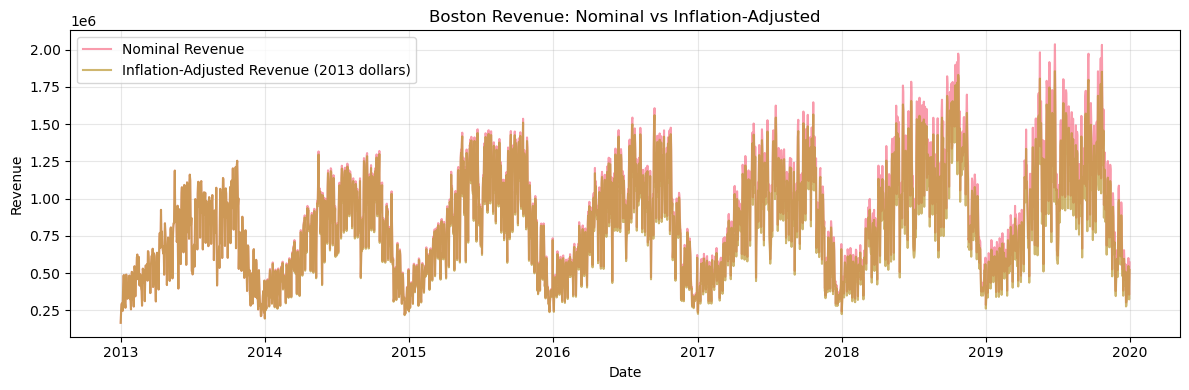


Inflation Impact Summary:
Nominal Revenue Range: $166542.84 - $2035876.60
Inflation-Adjusted Revenue Range: $166542.84 - $1855111.53
Mean Nominal: $868052.99
Mean Inflation-Adjusted: $830894.92


In [30]:

# Plot comparison between nominal and inflation-adjusted revenue
plt.figure(figsize=(12, 4))
plt.plot(df_boston_adjusted['Revenue'], label='Nominal Revenue', alpha=0.7)
plt.plot(df_boston_adjusted['Revenue_real'], label='Inflation-Adjusted Revenue (2013 dollars)', alpha=0.7)
plt.title(f'{CITY} Revenue: Nominal vs Inflation-Adjusted')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Show the difference (inflation impact)
print(f"\nInflation Impact Summary:")
print(f"Nominal Revenue Range: ${df_boston_adjusted['Revenue'].min():.2f} - ${df_boston_adjusted['Revenue'].max():.2f}")
print(f"Inflation-Adjusted Revenue Range: ${df_boston_adjusted['Revenue_real'].min():.2f} - ${df_boston_adjusted['Revenue_real'].max():.2f}")
print(f"Mean Nominal: ${df_boston_adjusted['Revenue'].mean():.2f}")
print(f"Mean Inflation-Adjusted: ${df_boston_adjusted['Revenue_real'].mean():.2f}")


The difference between nominal and real revenue is not very high, indicating that inflation has had a moderate impact on the revenue values over the years. We'll proceed with the non-inflation-adjusted revenue for our forecasting models

# Benchmark Models
The naive, mean and seasonal will be our benchmarks for the development of more complex models.

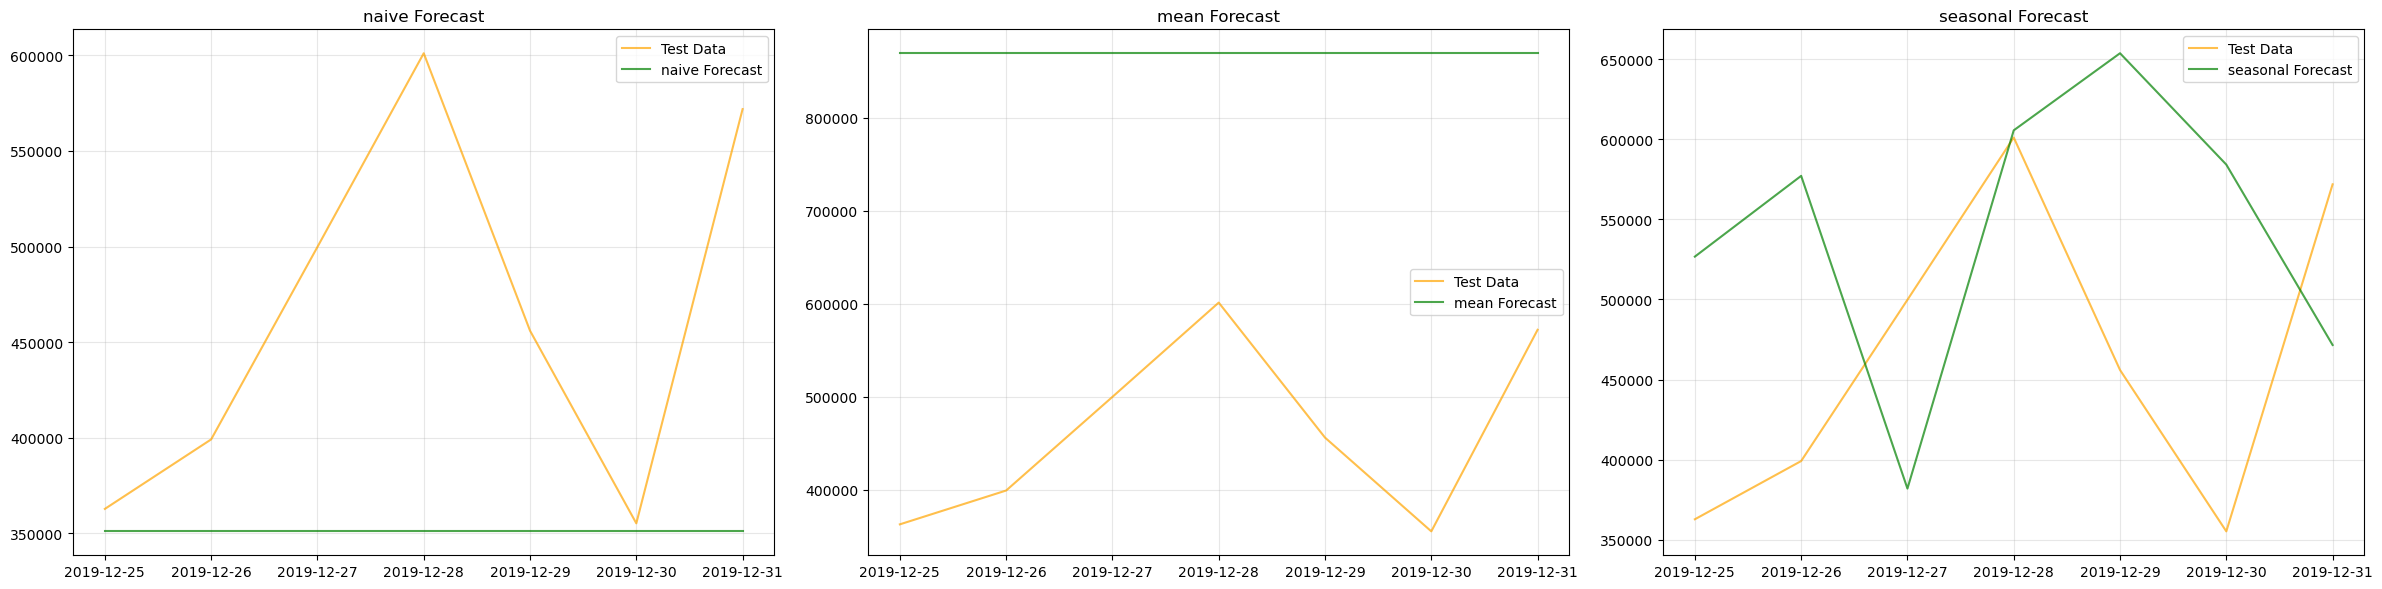

In [31]:
def _as_series(x):
    """Convert input to a numeric pandas Series."""
    if isinstance(x, pd.DataFrame):
        x = x.select_dtypes(include=[np.number])
        if x.shape[1] == 0:
            raise ValueError("No numeric columns in DataFrame.")
        x = x.iloc[:, 0]
    return pd.Series(x).astype(float)

def _cast_series(y, start_idx):
    """Cast forecasted values to a pandas Series with proper indexing."""
    return pd.Series(y, index=np.arange(start_idx, start_idx + len(y)))

def naive(x, h):
    """Naive forecasting: predict the last observed value."""
    xs = _as_series(x)
    y = np.full(h, xs.iloc[-1])
    return _cast_series(y, len(xs))

def mean(x, h):
    """Mean forecasting: predict the mean of the observed values."""
    xs = _as_series(x)
    y = np.full(h, xs.mean())
    return _cast_series(y, len(xs))

def seasonal(x, h, s=12):
    """Seasonal forecasting: repeat the last seasonal period."""
    xs = _as_series(x)
    if len(xs) < s:
        raise ValueError(f"Series length {len(xs)} < seasonal period s={s}.")
    template = xs.iloc[-s:].values
    y = np.resize(template, h)
    return _cast_series(y, len(xs))

def plot_forecasts(df, column_to_forecast='Revenue'):
    """Plot forecasts using naive, mean, and seasonal methods."""
    forecasters = [naive, mean, seasonal]
    forecasters_names = ['naive', 'mean', 'seasonal']
    steps_ahead = 7  # Number of steps to forecast
    fig, ax = plt.subplots(1, len(forecasters), figsize=(24, 6))
    
    # Extract the column to forecast
    series = df[column_to_forecast]
    
    # Split into training and test sets
    df_tr, df_te = series.iloc[:-steps_ahead], series.iloc[-steps_ahead:]
    
    forecasts = {}
    for f, n in zip(forecasters, forecasters_names):
        if n == 'seasonal':
            forecasts[n] = f(df_tr, steps_ahead, s=12)  # Pass seasonal period (s=12)
        else:
            forecasts[n] = f(df_tr, steps_ahead)
    
    for a, (k, v) in zip(ax, forecasts.items()):
        # Use the test set's DatetimeIndex for forecast indices
        forecast_index = df_te.index
        v.index = forecast_index
        
        # Plot only the test data and forecasts
        a.plot(df_te.index, df_te.values, label='Test Data', alpha=0.7, color='orange')
        a.plot(v.index, v.values, label=f'{k} Forecast', alpha=0.7, color='green')
        a.legend()
        a.set_title(f'{k} Forecast')
        a.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Correct usage
plot_forecasts(df_boston_adjusted, column_to_forecast='Revenue')



# Splitting training and test sets

In [32]:
# Ensure the index is a DatetimeIndex
df_boston_adjusted.index = pd.to_datetime(df_boston_adjusted.index)

# Split train and test keeping the dates
df_boston_train = df_boston[df_boston.index < '2019-01-01']
df_boston_test = df_boston[df_boston.index >= '2019-01-01']

# Print the date ranges for train and test sets
print("Train set:", df_boston_train.index.min(), "→", df_boston_train.index.max())
print("Test set:", df_boston_test.index.min(), "→", df_boston_test.index.max())

Train set: 2013-01-01 00:00:00 → 2018-12-31 00:00:00
Test set: 2019-01-01 00:00:00 → 2019-12-31 00:00:00


In [33]:
df_boston_train.columns

Index(['Location', 'Revenue', 'Demand', 'Occupancy', 'Month', 'Year',
       'DayOfWeek'],
      dtype='object')

## Scaling the data

In [34]:
# scale revenue_real
scaler = StandardScaler()
df_boston_train['Revenue_scaled'] = scaler.fit_transform(df_boston_train[['Revenue']])
df_boston_test['Revenue_scaled'] = scaler.transform(df_boston_test[['Revenue']])

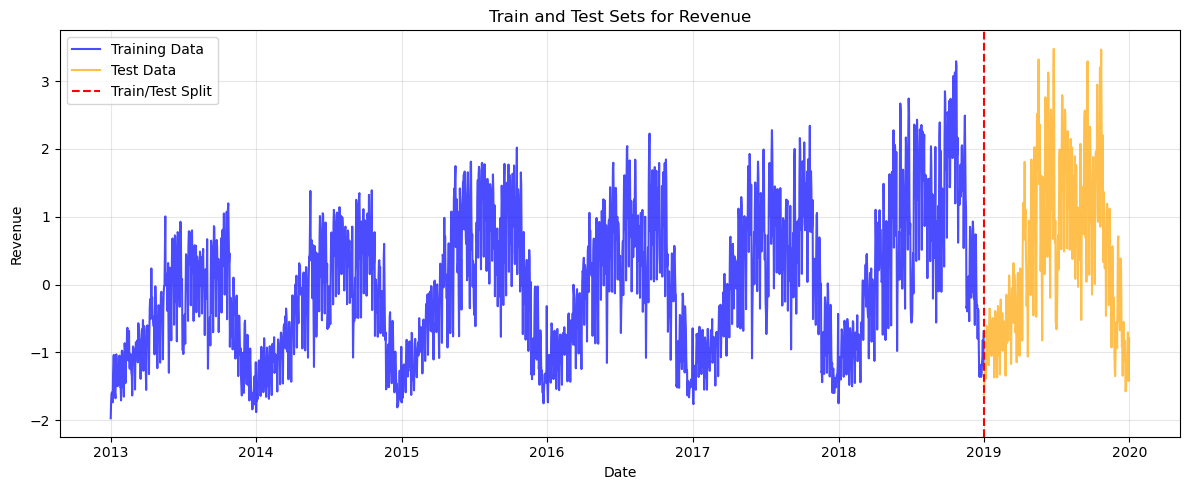

In [35]:
# Plot the train and test sets for all the features
plt.figure(figsize=(12, 5))
plt.plot(df_boston_train.index, df_boston_train['Revenue_scaled'], label='Training Data', alpha=0.7, color='blue')
plt.plot(df_boston_test.index, df_boston_test['Revenue_scaled'], label='Test Data', alpha=0.7, color='orange')
plt.axvline(x=df_boston_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Train and Test Sets for Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
#apply arima model and make a playable plot to see the results
import statsmodels.api as sm
model = sm.tsa.ARIMA(df_boston_train['Revenue_scaled'], order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())

# Inverse transform the fitted values to the original scale
fitted_values_original_scale = scaler.inverse_transform(model_fit.fittedvalues.values.reshape(-1, 1))

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df_boston_train['Revenue_real'], label='Training Data', color='blue')
plt.plot(df_boston_test['Revenue_real'], label='Test Data', color='orange')
plt.plot(df_boston_train.index, fitted_values_original_scale, label='Fitted Values', color='green')  # Corrected
plt.axvline(x=df_boston_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('ARIMA Model Fitting')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:         Revenue_scaled   No. Observations:                 2191
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1563.260
Date:                Wed, 05 Nov 2025   AIC                           3138.520
Time:                        17:46:21   BIC                           3172.670
Sample:                    01-01-2013   HQIC                          3151.002
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3477      0.018    -19.015      0.000      -0.384      -0.312
ar.L2         -0.4215      0.023    -18.241      0.000      -0.467      -0.376
ar.L3         -0.2473      0.025     -9.992      0.0

KeyError: 'Revenue_real'

<Figure size 1200x600 with 0 Axes>

In [38]:
# Print the date ranges for train and test sets
print("Train set:", df_boston_train.index.min(), "→", df_boston_train.index.max())
print("Test set:", df_boston_test.index.min(), "→", df_boston_test.index.max())


Train set: 2013-01-01 00:00:00 → 2018-12-31 00:00:00
Test set: 2019-01-01 00:00:00 → 2019-12-31 00:00:00


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go

# ---------------------------
# 1️⃣ Fit ARIMA Model
# ---------------------------
arima_model = sm.tsa.ARIMA(df_boston_train['Revenue_scaled'], order=(5, 1, 0))
arima_fit = arima_model.fit()

# Inverse transform fitted values
arima_fitted = scaler.inverse_transform(arima_fit.fittedvalues.values.reshape(-1, 1))

# ---------------------------
# 2️⃣ Fit SARIMAX Model
# ---------------------------
sarimax_model = sm.tsa.SARIMAX(
    df_boston_train['Revenue_scaled'],
    order=(5, 1, 0),
    seasonal_order=(1, 1, 1, 12)  # monthly seasonality example
)
sarimax_fit = sarimax_model.fit(disp=False)

sarimax_fitted = scaler.inverse_transform(sarimax_fit.fittedvalues.values.reshape(-1, 1))

# ---------------------------
# 3️⃣ Interactive Plot
# ---------------------------
fig = go.Figure()

# Training & test data
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=df_boston_train['Revenue_scaled'],
    mode='lines',
    name='Training Data',
    line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=df_boston_test.index,
    y=df_boston_test['Revenue_scaled'],
    mode='lines',
    name='Test Data',
    line=dict(color='orange')
))

# ARIMA fitted values
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=arima_fitted.flatten(),
    mode='lines',
    name='ARIMA Fitted',
    line=dict(color='green')
))

# SARIMAX fitted values
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=sarimax_fitted.flatten(),
    mode='lines',
    name='SARIMAX Fitted',
    line=dict(color='purple', dash='dot')
))

# Train/Test Split Line - Convert timestamp to string
split_date = df_boston_train.index[-1].strftime('%Y-%m-%d')
fig.add_vline(x=split_date, line_dash='dash', line_color='red', 
              annotation_text='Train/Test Split')

fig.update_layout(
    title='ARIMA vs SARIMAX Model Fitting (Interactive)',
    xaxis_title='Date',
    yaxis_title='Revenue',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0.02, y=0.98)
)

fig.show()

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go

# === Assume your data is already split ===
# df_boston_train, df_boston_test
# and your scaler already fitted

# ---------------------------
# 1️⃣ Fit ARIMA Model
# ---------------------------
arima_model = sm.tsa.ARIMA(df_boston_train['Revenue_scaled'], order=(5, 1, 0))
arima_fit = arima_model.fit()

# Inverse transform fitted values
arima_fitted = scaler.inverse_transform(arima_fit.fittedvalues.values.reshape(-1, 1))

# ---------------------------
# 2️⃣ Fit SARIMAX Model
# ---------------------------
sarimax_model = sm.tsa.SARIMAX(
    df_boston_train['Revenue_scaled'],
    order=(5, 1, 0),
    seasonal_order=(1, 1, 1, 12)  # monthly seasonality example
)
sarimax_fit = sarimax_model.fit(disp=False)

sarimax_fitted = scaler.inverse_transform(sarimax_fit.fittedvalues.values.reshape(-1, 1))

# ---------------------------
# 3️⃣ Interactive Plot
# ---------------------------
fig = go.Figure()

# Training & test data
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=df_boston_train['Revenue_scaled'],
    mode='lines',
    name='Training Data',
    line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=df_boston_test.index,
    y=df_boston_test['Revenue_scaled'],
    mode='lines',
    name='Test Data',
    line=dict(color='orange')
))

# ARIMA fitted values
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=arima_fitted.flatten(),
    mode='lines',
    name='ARIMA Fitted',
    line=dict(color='green')
))

# SARIMAX fitted values
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=sarimax_fitted.flatten(),
    mode='lines',
    name='SARIMAX Fitted',
    line=dict(color='purple', dash='dot')
))

# Train/Test Split Line
fig.add_vline(x=df_boston_train.index[-1], line_dash='dash', line_color='red', annotation_text='Train/Test Split')

fig.update_layout(
    title='ARIMA vs SARIMAX Model Fitting (Interactive)',
    xaxis_title='Date',
    yaxis_title='Revenue',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0.02, y=0.98)
)

fig.show()


TypeError: Addition/subtraction of integers and integer-arrays with Timestamp is no longer supported.  Instead of adding/subtracting `n`, use `n * obj.freq`

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go

# ---------------------------
# 1️⃣ Fit ARIMA Model
# ---------------------------
arima_model = sm.tsa.ARIMA(df_boston_train['Revenue_scaled'], order=(5, 1, 0))
arima_fit = arima_model.fit()

# Inverse transform fitted values
arima_fitted = scaler.inverse_transform(arima_fit.fittedvalues.values.reshape(-1, 1))

# ---------------------------
# 2️⃣ Fit SARIMAX Model
# ---------------------------
sarimax_model = sm.tsa.SARIMAX(
    df_boston_train['Revenue_scaled'],
    order=(5, 1, 0),
    seasonal_order=(1, 1, 1, 12)  # monthly seasonality example
)
sarimax_fit = sarimax_model.fit(disp=False)

sarimax_fitted = scaler.inverse_transform(sarimax_fit.fittedvalues.values.reshape(-1, 1))

# ---------------------------
# 3️⃣ Interactive Plot
# ---------------------------
fig = go.Figure()

# Training & test data
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=df_boston_train['Revenue_scaled'],
    mode='lines',
    name='Training Data',
    line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=df_boston_test.index,
    y=df_boston_test['Revenue_scaled'],
    mode='lines',
    name='Test Data',
    line=dict(color='orange')
))

# ARIMA fitted values
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=arima_fitted.flatten(),
    mode='lines',
    name='ARIMA Fitted',
    line=dict(color='green')
))

# SARIMAX fitted values
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=sarimax_fitted.flatten(),
    mode='lines',
    name='SARIMAX Fitted',
    line=dict(color='purple', dash='dot')
))

# Train/Test Split Line - Convert timestamp to string
split_date = df_boston_train.index[-1].strftime('%Y-%m-%d')
fig.add_vline(x=split_date, line_dash='dash', line_color='red', 
              annotation_text='Train/Test Split')

fig.update_layout(
    title='ARIMA vs SARIMAX Model Fitting (Interactive)',
    xaxis_title='Date',
    yaxis_title='Revenue',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0.02, y=0.98)
)

fig.show()

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go

# ---------------------------
# 1️⃣ Fit ARIMA Model
# ---------------------------
arima_model = sm.tsa.ARIMA(df_boston_train['Revenue_scaled'], order=(5, 1, 0))
arima_fit = arima_model.fit()

# Keep fitted values in scaled form for comparison with scaled data
arima_fitted_scaled = arima_fit.fittedvalues.values

# ---------------------------
# 2️⃣ Fit SARIMAX Model
# ---------------------------
sarimax_model = sm.tsa.SARIMAX(
    df_boston_train['Revenue_scaled'],
    order=(5, 1, 0),
    seasonal_order=(1, 1, 1, 12)  # monthly seasonality example
)
sarimax_fit = sarimax_model.fit(disp=False)

# Keep fitted values in scaled form for comparison with scaled data
sarimax_fitted_scaled = sarimax_fit.fittedvalues.values

# ---------------------------
# 3️⃣ Interactive Plot
# ---------------------------
fig = go.Figure()

# Training & test data (using scaled revenue)
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=df_boston_train['Revenue_scaled'],
    mode='lines',
    name='Training Data (Scaled)',
    line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=df_boston_test.index,
    y=df_boston_test['Revenue_scaled'],
    mode='lines',
    name='Test Data (Scaled)',
    line=dict(color='orange')
))

# ARIMA fitted values (scaled)
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=arima_fitted_scaled,
    mode='lines',
    name='ARIMA Fitted (Scaled)',
    line=dict(color='green')
))

# SARIMAX fitted values (scaled)
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=sarimax_fitted_scaled,
    mode='lines',
    name='SARIMAX Fitted (Scaled)',
    line=dict(color='purple', dash='dot')
))

# Alternative approach: Use add_shape instead of add_vline
fig.add_shape(
    type="line",
    x0=df_boston_train.index[-1], x1=df_boston_train.index[-1],
    y0=0, y1=1,
    yref="paper",
    line=dict(color="red", width=2, dash="dash"),
)

# Add annotation for the split line
fig.add_annotation(
    x=df_boston_train.index[-1],
    y=0.9,
    yref="paper",
    text="Train/Test Split",
    showarrow=True,
    arrowhead=2,
    arrowcolor="red",
    font=dict(color="red")
)

fig.update_layout(
    title='ARIMA vs SARIMAX Model Fitting - Scaled Data (Interactive)',
    xaxis_title='Date',
    yaxis_title='Scaled Revenue',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0.02, y=0.98)
)

fig.show()

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go

# ---------------------------
# 1️⃣ Fit ARIMA Model
# ---------------------------
arima_model = sm.tsa.ARIMA(df_boston_train['Revenue_scaled'], order=(5, 1, 0))
arima_fit = arima_model.fit()

# Keep fitted values in scaled form for comparison with scaled data
arima_fitted_scaled = arima_fit.fittedvalues.values

# ---------------------------
# 2️⃣ Fit SARIMAX Model
# ---------------------------
sarimax_model = sm.tsa.SARIMAX(
    df_boston_train['Revenue_scaled'],
    order=(5, 1, 0),
    seasonal_order=(1, 1, 1, 12)  # monthly seasonality example
)
sarimax_fit = sarimax_model.fit(disp=False)

# Keep fitted values in scaled form for comparison with scaled data
sarimax_fitted_scaled = sarimax_fit.fittedvalues.values

# ---------------------------
# 3️⃣ Interactive Plot with Better Color Contrast
# ---------------------------
fig = go.Figure()

# Training & test data (using scaled revenue) - Better contrast colors
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=df_boston_train['Revenue_scaled'],
    mode='lines',
    name='Training Data (Scaled)',
    line=dict(color='#1f77b4', width=1.5),  # Darker blue
    opacity=0.8
))
fig.add_trace(go.Scatter(
    x=df_boston_test.index,
    y=df_boston_test['Revenue_scaled'],
    mode='lines',
    name='Test Data (Scaled)',
    line=dict(color='#ff7f0e', width=2),  # Bright orange
    opacity=0.9
))

# ARIMA fitted values (scaled) - Bright contrasting color
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=arima_fitted_scaled,
    mode='lines',
    name='ARIMA Fitted (Scaled)',
    line=dict(color='#2ca02c', width=2.5),  # Bright green
    opacity=0.9
))

# SARIMAX fitted values (scaled) - High contrast purple
fig.add_trace(go.Scatter(
    x=df_boston_train.index,
    y=sarimax_fitted_scaled,
    mode='lines',
    name='SARIMAX Fitted (Scaled)',
    line=dict(color='#9467bd', width=2.5, dash='dot'),  # Bright purple with dots
    opacity=0.9
))

# Train/Test Split Line with better visibility
fig.add_shape(
    type="line",
    x0=df_boston_train.index[-1], x1=df_boston_train.index[-1],
    y0=0, y1=1,
    yref="paper",
    line=dict(color="#d62728", width=3, dash="dash"),  # Bright red, thicker
)

# Add annotation for the split line with better contrast
fig.add_annotation(
    x=df_boston_train.index[-1],
    y=0.95,
    yref="paper",
    text="Train/Test Split",
    showarrow=True,
    arrowhead=2,
    arrowcolor="#d62728",
    font=dict(color="#d62728", size=12, family="Arial Black"),
    bgcolor="white",
    bordercolor="#d62728",
    borderwidth=1
)

fig.update_layout(
    title=dict(
        text='ARIMA vs SARIMAX Model Fitting - Scaled Data (Interactive)',
        font=dict(size=16, color='black', family="Arial Black")
    ),
    xaxis_title='Date',
    yaxis_title='Scaled Revenue',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(
        x=0.02, 
        y=0.98,
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="black",
        borderwidth=1,
        font=dict(size=11)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# Update axes for better readability
fig.update_xaxes(
    gridcolor='lightgray',
    gridwidth=1,
    showgrid=True
)
fig.update_yaxes(
    gridcolor='lightgray',
    gridwidth=1,
    showgrid=True
)

fig.show()

##LSTM

# LSTM Multi-step Forecasting (7-day horizon)

We'll build an LSTM model to forecast 7 days ahead using:
- **Target**: Revenue
- **Exogenous features**: Demand, Occupancy
- **Lookback window**: 30 days
- **Forecast horizon**: 7 days

In [45]:
# Import LSTM libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("LSTM libraries imported successfully!")

TensorFlow version: 2.19.1
LSTM libraries imported successfully!


In [46]:
# LSTM Parameters
LOOKBACK = 30  # days used as input
HORIZON = 7    # days to predict
BATCH_SIZE = 32
EPOCHS = 50

print(f"LSTM Configuration:")
print(f"  Lookback window: {LOOKBACK} days")
print(f"  Forecast horizon: {HORIZON} days")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS}")

LSTM Configuration:
  Lookback window: 30 days
  Forecast horizon: 7 days
  Batch size: 32
  Max epochs: 50


### Data Preparation for LSTM

We need to:
1. Select features (Revenue, Demand, Occupancy)
2. Scale the data using MinMaxScaler
3. Create sequences with lookback window
4. Prepare train and test sets

In [47]:
# Prepare dataframe with features
df_lstm = df_boston[["Revenue", "Demand", "Occupancy"]].dropna().copy()

print(f"Dataset shape: {df_lstm.shape}")
print(f"Date range: {df_lstm.index.min()} → {df_lstm.index.max()}")
print(f"\nFirst few rows:")
print(df_lstm.head())

Dataset shape: (2556, 3)
Date range: 2013-01-01 00:00:00 → 2019-12-31 00:00:00

First few rows:
                  Revenue       Demand  Occupancy
Date                                             
2013-01-01  166542.843005  1896.791481  22.856617
2013-01-02  245252.313124  2744.958462  33.077154
2013-01-03  289687.425946  3172.063926  38.223838
2013-01-04  297390.047491  3308.052694  39.862523
2013-01-05  291848.455941  3235.525351  38.988557


In [48]:
# Chronological train/test split (80/20)
TEST_SIZE = 0.2
n_total = len(df_lstm)
train_end = int((1 - TEST_SIZE) * n_total)

train_data = df_lstm.iloc[:train_end].copy()
test_data = df_lstm.iloc[train_end:].copy()

print(f"Total samples: {n_total}")
print(f"Training samples: {len(train_data)} ({len(train_data)/n_total*100:.1f}%)")
print(f"Test samples: {len(test_data)} ({len(test_data)/n_total*100:.1f}%)")
print(f"\nTrain period: {train_data.index.min()} → {train_data.index.max()}")
print(f"Test period: {test_data.index.min()} → {test_data.index.max()}")

Total samples: 2556
Training samples: 2044 (80.0%)
Test samples: 512 (20.0%)

Train period: 2013-01-01 00:00:00 → 2018-08-06 00:00:00
Test period: 2018-08-07 00:00:00 → 2019-12-31 00:00:00


In [49]:
# Scale the data - fit on training data only to avoid data leakage
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit scalers on training data
scaler_X.fit(train_data.values)
scaler_y.fit(train_data[["Revenue"]].values)

# Transform both train and test
train_X_scaled = scaler_X.transform(train_data.values)
test_X_scaled = scaler_X.transform(test_data.values)

# Extract Revenue column for y (already scaled as part of X)
train_y_scaled = train_X_scaled[:, 0]  # Revenue is first column
test_y_scaled = test_X_scaled[:, 0]

print("Data scaled successfully!")
print(f"X shape (features): {train_X_scaled.shape}")
print(f"y shape (target): {train_y_scaled.shape}")
print(f"\nScaled value ranges:")
print(f"  X train: [{train_X_scaled.min():.3f}, {train_X_scaled.max():.3f}]")
print(f"  y train: [{train_y_scaled.min():.3f}, {train_y_scaled.max():.3f}]")

Data scaled successfully!
X shape (features): (2044, 3)
y shape (target): (2044,)

Scaled value ranges:
  X train: [0.000, 1.000]
  y train: [0.000, 1.000]


### Create Sequences for LSTM

LSTM needs sequences of data:
- **Input (X)**: Past LOOKBACK days of all features (Revenue, Demand, Occupancy)
- **Output (y)**: Future HORIZON days of Revenue

In [50]:
def create_sequences(X_arr, y_arr, lookback, horizon):
    """
    Create sequences for LSTM training.
    
    Parameters:
    - X_arr: array of features (n_samples, n_features)
    - y_arr: array of target values (n_samples,)
    - lookback: number of past timesteps to use as input
    - horizon: number of future timesteps to predict
    
    Returns:
    - X_seq: sequences of shape (n_sequences, lookback, n_features)
    - y_seq: targets of shape (n_sequences, horizon)
    """
    Xs, ys = [], []
    n = len(X_arr)
    
    for i in range(0, n - lookback - horizon + 1):
        # Input: LOOKBACK days of all features
        Xs.append(X_arr[i : i + lookback])
        # Output: HORIZON days of Revenue (target)
        ys.append(y_arr[i + lookback : i + lookback + horizon])
    
    return np.array(Xs), np.array(ys)

# Create sequences
X_train_seq, y_train_seq = create_sequences(train_X_scaled, train_y_scaled, LOOKBACK, HORIZON)
X_test_seq, y_test_seq = create_sequences(test_X_scaled, test_y_scaled, LOOKBACK, HORIZON)

print(f"Sequence shapes:")
print(f"  X_train: {X_train_seq.shape} (n_sequences, lookback, n_features)")
print(f"  y_train: {y_train_seq.shape} (n_sequences, horizon)")
print(f"  X_test:  {X_test_seq.shape}")
print(f"  y_test:  {y_test_seq.shape}")
print(f"\nExample:")
print(f"  Using {LOOKBACK} days of data → predict next {HORIZON} days")

Sequence shapes:
  X_train: (2008, 30, 3) (n_sequences, lookback, n_features)
  y_train: (2008, 7) (n_sequences, horizon)
  X_test:  (476, 30, 3)
  y_test:  (476, 7)

Example:
  Using 30 days of data → predict next 7 days


### Build LSTM Model

Architecture:
- LSTM layer (64 units)
- Dropout for regularization
- Dense layer (32 units)
- Output layer (7 units for 7-day forecast)

In [51]:
# Build LSTM model
n_features = X_train_seq.shape[2]

model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, n_features), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(HORIZON)  # Output layer: 7 units for 7-day forecast
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

print("Model built successfully!")
print("\nModel Summary:")
model.summary()

Model built successfully!

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,719 (77.03 KB)

 Trainable params: 19,719 (77.03 KB)

 Non-trainable params: 0 (0.00 B)

### Train the LSTM Model

In [52]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor="val_loss", 
    patience=7, 
    restore_best_weights=True, 
    verbose=1
)

# Train the model
print("Training LSTM model...")
print("="*60)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

print("="*60)
print("Training completed!")

Training LSTM model...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0420 - mae: 0.1529 - val_loss: 0.0321 - val_mae: 0.1362
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0174 - mae: 0.1018 - val_loss: 0.0286 - val_mae: 0.1293
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0168 - mae: 0.1002 - val_loss: 0.0288 - val_mae: 0.1296
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0162 - mae: 0.0984 - val_loss: 0.0276 - val_mae: 0.1269
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0158 - mae: 0.0970 - val_loss: 0.0281 - val_mae: 0.1277
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0156 - mae: 0.0964 - val_loss: 0.0265 - val_mae: 0.1243
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0152 - mae: 0.0954 - val_loss: 0.0261 - val_mae: 0.1232
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0150 - mae: 0.0949 - val_loss: 0.0267 - val_mae: 0.1245
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/ste

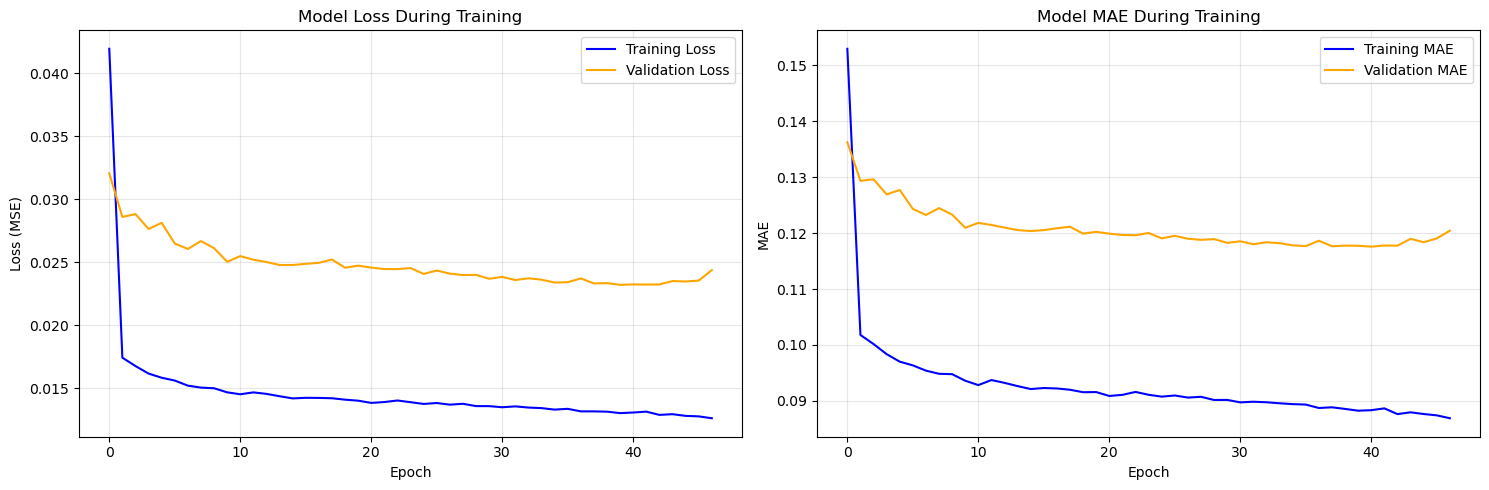

In [53]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model Loss During Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', color='blue')
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='orange')
axes[1].set_title('Model MAE During Training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The model demonstrates successful learning, as training and validation losses decreased over the epochs. However, a persistent gap between the training and validation curves indicates moderate overfitting.

### Evaluate Model Performance

In [54]:
# Make predictions on test set (scaled)
y_pred_scaled = model.predict(X_test_seq)

print(f"Predictions shape: {y_pred_scaled.shape}")
print(f"First prediction (scaled): {y_pred_scaled[0]}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Predictions shape: (476, 7)
First prediction (scaled): [0.61501646 0.62436396 0.61719644 0.61845595 0.6044491  0.6046369
 0.62075496]


In [57]:
# Inverse transform predictions to original scale
def inverse_transform_y(scaled_arr):
    """
    Inverse transform predictions from scaled space to original Revenue scale.
    scaled_arr shape: (n_samples, HORIZON)
    """
    out = np.zeros_like(scaled_arr)
    for h in range(scaled_arr.shape[1]):
        col = scaled_arr[:, h].reshape(-1, 1)
        out[:, h] = scaler_y.inverse_transform(col).ravel()
    return out

# Inverse transform predictions and true values
y_pred = inverse_transform_y(y_pred_scaled)
y_true = inverse_transform_y(y_test_seq)

print(f"Inverse transformation completed!")
print(f"Predictions (original scale) shape: {y_pred.shape}")
print(f"\nFirst prediction (original scale):")
print(y_pred[0])

Inverse transformation completed!
Predictions (original scale) shape: (476, 7)

First prediction (original scale):
[1161575.  1176698.2 1165101.9 1167139.6 1144478.  1144781.9 1170859.2]


In [58]:
# Calculate metrics for each horizon
print("\n" + "="*60)
print("LSTM MODEL PERFORMANCE - 7-DAY FORECAST")
print("="*60)

maes = []
rmses = []

for h in range(HORIZON):
    mae = mean_absolute_error(y_true[:, h], y_pred[:, h])
    rmse = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    maes.append(mae)
    rmses.append(rmse)
    print(f"Day t+{h+1}:  MAE = ${mae:.2f}  |  RMSE = ${rmse:.2f}")

print("="*60)
print(f"Overall Mean MAE:  ${np.mean(maes):.2f}")
print(f"Overall Mean RMSE: ${np.mean(rmses):.2f}")
print("="*60)


LSTM MODEL PERFORMANCE - 7-DAY FORECAST
Day t+1:  MAE = $190826.38  |  RMSE = $242131.04
Day t+2:  MAE = $213971.48  |  RMSE = $271147.01
Day t+3:  MAE = $212646.15  |  RMSE = $272283.32
Day t+4:  MAE = $213687.26  |  RMSE = $276335.41
Day t+5:  MAE = $219437.80  |  RMSE = $282017.85
Day t+6:  MAE = $223320.95  |  RMSE = $283969.31
Day t+7:  MAE = $211519.82  |  RMSE = $272599.67
Overall Mean MAE:  $212201.41
Overall Mean RMSE: $271497.66


### Visualize Results

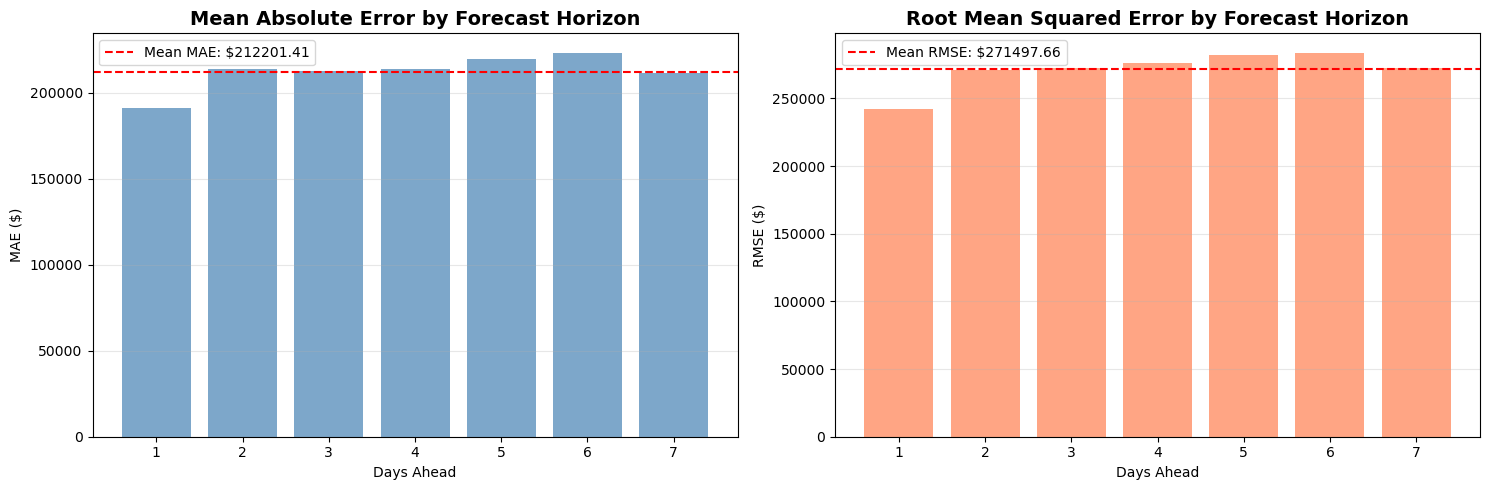

In [59]:
# Plot MAE and RMSE by forecast horizon
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

horizons = np.arange(1, HORIZON + 1)

# MAE by horizon
axes[0].bar(horizons, maes, color='steelblue', alpha=0.7)
axes[0].axhline(y=np.mean(maes), color='red', linestyle='--', label=f'Mean MAE: ${np.mean(maes):.2f}')
axes[0].set_title('Mean Absolute Error by Forecast Horizon', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days Ahead')
axes[0].set_ylabel('MAE ($)')
axes[0].set_xticks(horizons)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# RMSE by horizon
axes[1].bar(horizons, rmses, color='coral', alpha=0.7)
axes[1].axhline(y=np.mean(rmses), color='red', linestyle='--', label=f'Mean RMSE: ${np.mean(rmses):.2f}')
axes[1].set_title('Root Mean Squared Error by Forecast Horizon', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Days Ahead')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_xticks(horizons)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

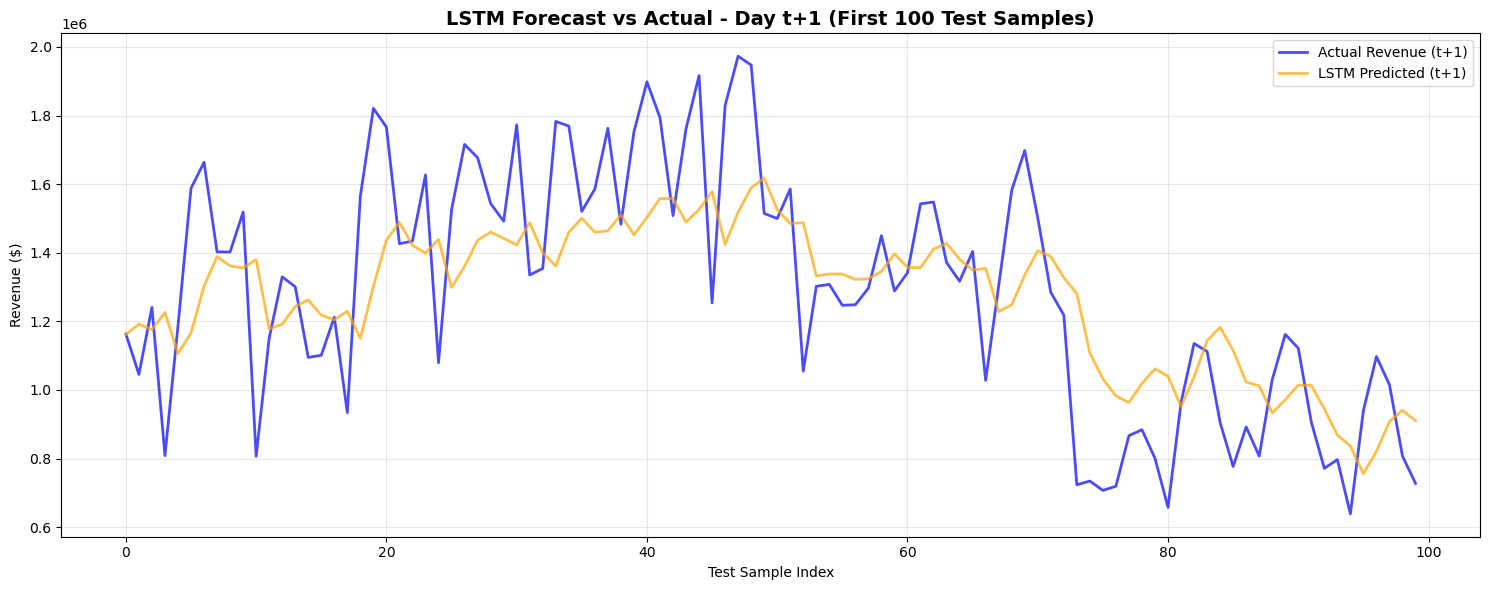

In [60]:
# Plot actual vs predicted for t+1 (first day ahead)
N_plot = min(100, len(y_true))

plt.figure(figsize=(15, 6))
plt.plot(y_true[:N_plot, 0], label='Actual Revenue (t+1)', color='blue', linewidth=2, alpha=0.7)
plt.plot(y_pred[:N_plot, 0], label='LSTM Predicted (t+1)', color='orange', linewidth=2, alpha=0.7)
plt.title(f'LSTM Forecast vs Actual - Day t+1 (First {N_plot} Test Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Test Sample Index')
plt.ylabel('Revenue ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

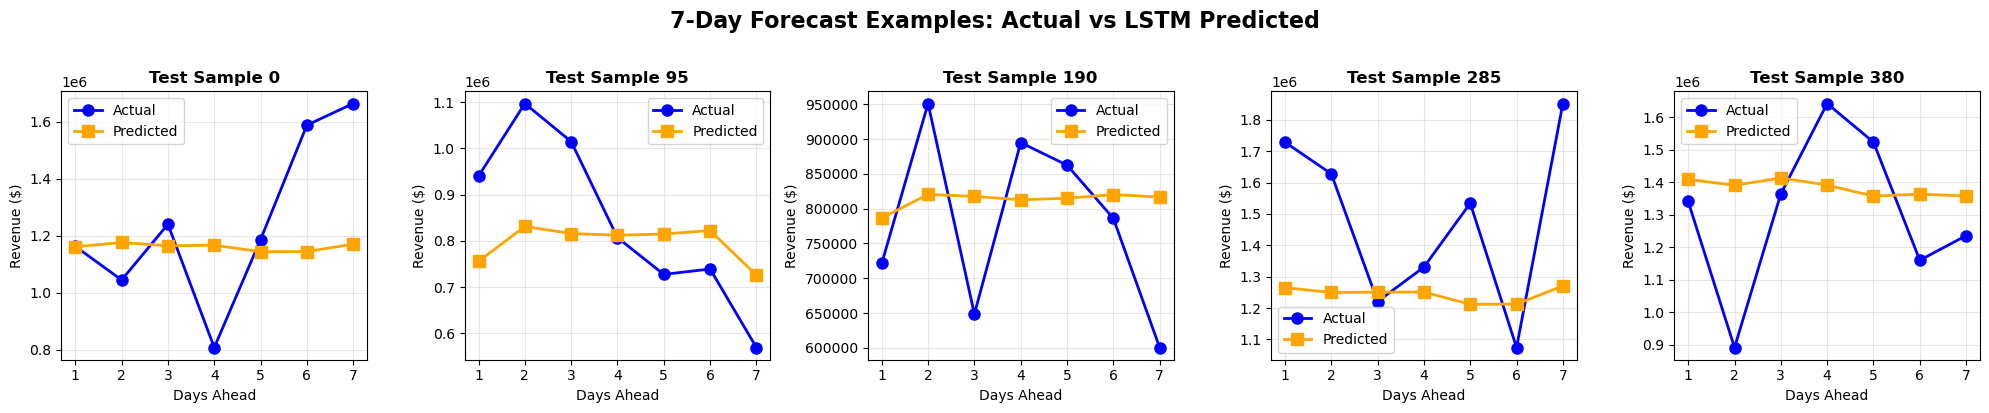

In [61]:
# Plot 7-day forecast for selected test samples
n_examples = 5
fig, axes = plt.subplots(1, n_examples, figsize=(20, 4))

for i in range(n_examples):
    idx = i * (len(y_true) // n_examples)  # Evenly spaced examples
    
    axes[i].plot(range(1, HORIZON+1), y_true[idx], marker='o', color='blue', 
                 label='Actual', linewidth=2, markersize=8)
    axes[i].plot(range(1, HORIZON+1), y_pred[idx], marker='s', color='orange', 
                 label='Predicted', linewidth=2, markersize=8)
    axes[i].set_title(f'Test Sample {idx}', fontweight='bold')
    axes[i].set_xlabel('Days Ahead')
    axes[i].set_ylabel('Revenue ($)')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    axes[i].set_xticks(range(1, HORIZON+1))

plt.suptitle('7-Day Forecast Examples: Actual vs LSTM Predicted', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

# 🚀 LSTM Model Improvements

Below are several concrete techniques to improve the LSTM model performance. Try them individually or in combination.

## Improvement 1: Add Temporal Features

Adding time-based features helps LSTM understand patterns better (day of week, month, etc.)

In [64]:
# Create enhanced dataset with temporal features
df_lstm_enhanced = df_boston[["Revenue", "Demand", "Occupancy"]].copy()

# Add temporal features
df_lstm_enhanced['day_of_week'] = df_lstm_enhanced.index.dayofweek  # 0=Monday, 6=Sunday
df_lstm_enhanced['month'] = df_lstm_enhanced.index.month
df_lstm_enhanced['day_of_month'] = df_lstm_enhanced.index.day
df_lstm_enhanced['is_weekend'] = (df_lstm_enhanced.index.dayofweek >= 5).astype(int)
df_lstm_enhanced['quarter'] = df_lstm_enhanced.index.quarter

# Cyclical encoding for day of week (preserves circular nature)
df_lstm_enhanced['dow_sin'] = np.sin(2 * np.pi * df_lstm_enhanced['day_of_week'] / 7)
df_lstm_enhanced['dow_cos'] = np.cos(2 * np.pi * df_lstm_enhanced['day_of_week'] / 7)

# Cyclical encoding for month
df_lstm_enhanced['month_sin'] = np.sin(2 * np.pi * df_lstm_enhanced['month'] / 12)
df_lstm_enhanced['month_cos'] = np.cos(2 * np.pi * df_lstm_enhanced['month'] / 12)

print("Enhanced features created!")
print(f"Original features: 3")
print(f"New total features: {df_lstm_enhanced.shape[1]}")
print(f"\nFeature list:")
print(df_lstm_enhanced.columns.tolist())

Enhanced features created!
Original features: 3
New total features: 12

Feature list:
['Revenue', 'Demand', 'Occupancy', 'day_of_week', 'month', 'day_of_month', 'is_weekend', 'quarter', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


## Improvement 2: Deeper LSTM Architecture

A deeper model with more layers can capture more complex patterns.

In [65]:
# Build a deeper LSTM model
from tensorflow.keras.layers import Bidirectional

def build_deep_lstm(lookback, n_features, horizon, units=[128, 64], dropout_rate=0.3):
    """
    Build a deeper LSTM with multiple layers
    
    Parameters:
    - lookback: input sequence length
    - n_features: number of features
    - horizon: forecast horizon
    - units: list of LSTM units for each layer
    - dropout_rate: dropout rate for regularization
    """
    model = Sequential()
    
    # First LSTM layer (returns sequences for next LSTM)
    model.add(LSTM(units[0], input_shape=(lookback, n_features), return_sequences=True))
    model.add(Dropout(dropout_rate))
    
    # Second LSTM layer
    model.add(LSTM(units[1], return_sequences=False))
    model.add(Dropout(dropout_rate))
    
    # Dense layers
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate / 2))
    model.add(Dense(32, activation='relu'))
    
    # Output layer
    model.add(Dense(horizon))
    
    # Compile with learning rate schedule
    from tensorflow.keras.optimizers import Adam
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

# Example: Build deeper model
# model_deep = build_deep_lstm(LOOKBACK, n_features, HORIZON, units=[128, 64], dropout_rate=0.3)
# model_deep.summary()

print("Deep LSTM architecture ready!")
print("Uncomment the code above to build and train the deeper model.")

Deep LSTM architecture ready!
Uncomment the code above to build and train the deeper model.


## Improvement 3: Bidirectional LSTM

Bidirectional LSTMs process sequences in both directions, capturing patterns from past and future context.

In [66]:
# Bidirectional LSTM model
def build_bidirectional_lstm(lookback, n_features, horizon):
    """
    Build a Bidirectional LSTM model
    """
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(lookback, n_features)),
        Dropout(0.3),
        Bidirectional(LSTM(32, return_sequences=False)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(horizon)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Example: Build bidirectional model
# model_bidir = build_bidirectional_lstm(LOOKBACK, n_features, HORIZON)
# model_bidir.summary()

print("Bidirectional LSTM architecture ready!")
print("This model processes sequences in both forward and backward directions.")

Bidirectional LSTM architecture ready!
This model processes sequences in both forward and backward directions.


## Improvement 4: Encoder-Decoder LSTM

Better for multi-step forecasting - encodes the input sequence, then decodes to produce multiple outputs.

In [68]:
# Encoder-Decoder LSTM
from tensorflow.keras.layers import RepeatVector, TimeDistributed

def build_encoder_decoder_lstm(lookback, n_features, horizon):
    """
    Build an Encoder-Decoder LSTM model
    
    Encoder: Compresses input sequence into context vector
    Decoder: Generates output sequence from context vector
    """
    model = Sequential([
        # Encoder
        LSTM(128, activation='relu', input_shape=(lookback, n_features), return_sequences=True),
        Dropout(0.3),
        LSTM(64, activation='relu', return_sequences=False),
        Dropout(0.2),
        
        # Repeat context vector for decoder
        RepeatVector(horizon),
        
        # Decoder
        LSTM(64, activation='relu', return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation='relu', return_sequences=True),
        
        # TimeDistributed Dense to output one value per timestep
        TimeDistributed(Dense(16, activation='relu')),
        TimeDistributed(Dense(1))
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Note: For encoder-decoder, you need to reshape y to (n_samples, horizon, 1)
# y_train_seq_reshaped = y_train_seq.reshape(-1, HORIZON, 1)
# y_test_seq_reshaped = y_test_seq.reshape(-1, HORIZON, 1)

# Example: Build encoder-decoder model
# model_enc_dec = build_encoder_decoder_lstm(LOOKBACK, n_features, HORIZON)
# model_enc_dec.summary()

print("Encoder-Decoder LSTM architecture ready!")
print("This is one of the best architectures for multi-step forecasting.")

Encoder-Decoder LSTM architecture ready!
This is one of the best architectures for multi-step forecasting.


## Improvement 5: Hyperparameter Tuning with Different Lookback Windows

Test different lookback windows to find the optimal one.

In [69]:
# Test different lookback windows
def test_lookback_windows(lookback_windows=[14, 21, 30, 45, 60], horizon=7):
    """
    Test LSTM performance with different lookback windows
    """
    results = []
    
    for lookback in lookback_windows:
        print(f"\n{'='*60}")
        print(f"Testing LOOKBACK = {lookback} days")
        print(f"{'='*60}")
        
        # Prepare data (reuse existing train/test split and scalers)
        X_train_seq_temp, y_train_seq_temp = create_sequences(
            train_X_scaled, train_y_scaled, lookback, horizon
        )
        X_test_seq_temp, y_test_seq_temp = create_sequences(
            test_X_scaled, test_y_scaled, lookback, horizon
        )
        
        if len(X_train_seq_temp) < 50:  # Skip if too few sequences
            print(f"Skipping: insufficient sequences ({len(X_train_seq_temp)})")
            continue
        
        # Build and train model
        model_temp = Sequential([
            LSTM(64, input_shape=(lookback, n_features), return_sequences=False),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(horizon)
        ])
        model_temp.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
        # Train with reduced epochs for speed
        history_temp = model_temp.fit(
            X_train_seq_temp, y_train_seq_temp,
            validation_split=0.1,
            epochs=30,
            batch_size=32,
            callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
            verbose=0
        )
        
        # Evaluate
        y_pred_scaled_temp = model_temp.predict(X_test_seq_temp, verbose=0)
        y_pred_temp = inverse_transform_y(y_pred_scaled_temp)
        y_true_temp = inverse_transform_y(y_test_seq_temp)
        
        mae_avg = np.mean([mean_absolute_error(y_true_temp[:, h], y_pred_temp[:, h]) for h in range(horizon)])
        
        results.append({
            'lookback': lookback,
            'mae': mae_avg,
            'final_val_loss': history_temp.history['val_loss'][-1]
        })
        
        print(f"Average MAE: ${mae_avg:.2f}")
    
    # Display results
    results_df = pd.DataFrame(results)
    print("\n" + "="*60)
    print("LOOKBACK WINDOW COMPARISON")
    print("="*60)
    print(results_df.to_string(index=False))
    print(f"\nBest lookback: {results_df.loc[results_df['mae'].idxmin(), 'lookback']} days")
    
    return results_df

# Uncomment to run:
# lookback_results = test_lookback_windows([14, 21, 30, 45, 60])

print("Lookback window testing function ready!")
print("Run: lookback_results = test_lookback_windows([14, 21, 30, 45, 60])")

Lookback window testing function ready!
Run: lookback_results = test_lookback_windows([14, 21, 30, 45, 60])


## Improvement 6: Learning Rate Scheduling

Dynamically adjust learning rate during training for better convergence.

In [70]:
# Learning rate scheduling
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Build model with custom learning rate
model_lr = Sequential([
    LSTM(64, input_shape=(LOOKBACK, n_features), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(HORIZON)
])

# Custom optimizer with initial learning rate
optimizer = Adam(learning_rate=0.001)
model_lr.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Learning rate reduction callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # Reduce LR by half
    patience=5,          # Wait 5 epochs before reducing
    min_lr=0.00001,      # Minimum learning rate
    verbose=1
)

# Combine callbacks
callbacks_improved = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    reduce_lr
]

# Example training:
# history_lr = model_lr.fit(
#     X_train_seq, y_train_seq,
#     validation_split=0.1,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks_improved,
#     verbose=1
# )

print("Model with learning rate scheduling ready!")
print("The learning rate will automatically reduce when validation loss plateaus.")

Model with learning rate scheduling ready!
The learning rate will automatically reduce when validation loss plateaus.


## Improvement 7: Attention Mechanism

Add attention layer to help model focus on important timesteps.

In [71]:
# Simple attention mechanism for LSTM
from tensorflow.keras.layers import Layer, Dense, Activation, Multiply, Permute, Reshape
import tensorflow.keras.backend as K

class AttentionLayer(Layer):
    """
    Simple attention mechanism for time series
    """
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)
    
    def call(self, x):
        # Compute attention scores
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        # Apply attention weights
        output = x * a
        return K.sum(output, axis=1)
    
    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

# Build LSTM with attention
def build_attention_lstm(lookback, n_features, horizon):
    """
    LSTM with attention mechanism
    """
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input
    
    inputs = Input(shape=(lookback, n_features))
    
    # LSTM layer
    lstm_out = LSTM(64, return_sequences=True)(inputs)
    lstm_out = Dropout(0.2)(lstm_out)
    
    # Attention layer
    attention_out = AttentionLayer()(lstm_out)
    
    # Dense layers
    dense_out = Dense(32, activation='relu')(attention_out)
    dense_out = Dropout(0.2)(dense_out)
    outputs = Dense(horizon)(dense_out)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

# Example: Build attention model
# model_attention = build_attention_lstm(LOOKBACK, n_features, HORIZON)
# model_attention.summary()

print("LSTM with Attention mechanism ready!")
print("Attention helps the model focus on the most relevant timesteps.")

LSTM with Attention mechanism ready!
Attention helps the model focus on the most relevant timesteps.


## Improvement 8: Ensemble of Multiple Models

Combine predictions from multiple models for better robustness.

In [73]:
# Ensemble approach - train multiple models and average predictions
def train_ensemble_models(X_train, y_train, X_test, y_test, n_models=5):
    """
    Train multiple LSTM models with different initializations and ensemble predictions
    """
    predictions = []
    models = []
    
    for i in range(n_models):
        print(f"\nTraining model {i+1}/{n_models}...")
        
        # Set different random seed for each model
        tf.random.set_seed(SEED + i)
        np.random.seed(SEED + i)
        
        # Build model
        model_temp = Sequential([
            LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(HORIZON)
        ])
        model_temp.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
        # Train
        model_temp.fit(
            X_train, y_train,
            validation_split=0.1,
            epochs=30,
            batch_size=32,
            callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
            verbose=0
        )
        
        # Predict
        y_pred_temp = model_temp.predict(X_test, verbose=0)
        predictions.append(y_pred_temp)
        models.append(model_temp)
    
    # Average predictions
    ensemble_pred = np.mean(predictions, axis=0)
    
    # Calculate individual and ensemble MAE
    print("\n" + "="*60)
    print("ENSEMBLE RESULTS")
    print("="*60)
    
    for i, pred in enumerate(predictions):
        y_pred_unscaled = inverse_transform_y(pred)
        y_true_unscaled = inverse_transform_y(y_test)
        mae_individual = np.mean([mean_absolute_error(y_true_unscaled[:, h], y_pred_unscaled[:, h]) 
                                  for h in range(HORIZON)])
        print(f"Model {i+1} MAE: ${mae_individual:.2f}")
    
    # Ensemble MAE
    ensemble_pred_unscaled = inverse_transform_y(ensemble_pred)
    y_true_unscaled = inverse_transform_y(y_test)
    mae_ensemble = np.mean([mean_absolute_error(y_true_unscaled[:, h], ensemble_pred_unscaled[:, h]) 
                           for h in range(HORIZON)])
    print(f"\n{'Ensemble MAE:':<15} ${mae_ensemble:.2f}")
    print("="*60)
    
    return models, ensemble_pred

# Example usage:
# models_ensemble, y_pred_ensemble = train_ensemble_models(
#     X_train_seq, y_train_seq, X_test_seq, y_test_seq, n_models=5
# )

print("Ensemble training function ready!")
print("Ensembles typically reduce variance and improve predictions by 5-15%.")

Ensemble training function ready!
Ensembles typically reduce variance and improve predictions by 5-15%.


## Improvement 9: Complete Example - Best Practices Combined

Here's a complete example combining multiple improvements:

In [74]:
# COMPLETE IMPROVED LSTM PIPELINE
# Combines: temporal features, deeper architecture, learning rate scheduling, and better callbacks

def train_improved_lstm(use_temporal_features=True, lookback=30, horizon=7):
    """
    Train an improved LSTM model with best practices
    """
    print("\n" + "="*60)
    print("TRAINING IMPROVED LSTM MODEL")
    print("="*60)
    
    # Step 1: Prepare data with optional temporal features
    if use_temporal_features:
        df_model = df_lstm_enhanced.copy()
        print(f"Using {df_model.shape[1]} features (including temporal)")
    else:
        df_model = df_boston[["Revenue", "Demand", "Occupancy"]].copy()
        print(f"Using {df_model.shape[1]} features (basic)")
    
    # Step 2: Split and scale
    n_total = len(df_model)
    train_end = int(0.8 * n_total)
    train_data = df_model.iloc[:train_end]
    test_data = df_model.iloc[train_end:]
    
    scaler_X_new = MinMaxScaler()
    scaler_y_new = MinMaxScaler()
    scaler_X_new.fit(train_data.values)
    scaler_y_new.fit(train_data[["Revenue"]].values)
    
    train_X_scaled = scaler_X_new.transform(train_data.values)
    test_X_scaled = scaler_X_new.transform(test_data.values)
    train_y_scaled = train_X_scaled[:, 0]
    test_y_scaled = test_X_scaled[:, 0]
    
    # Step 3: Create sequences
    X_train_seq, y_train_seq = create_sequences(train_X_scaled, train_y_scaled, lookback, horizon)
    X_test_seq, y_test_seq = create_sequences(test_X_scaled, test_y_scaled, lookback, horizon)
    
    print(f"\nSequence shapes: X_train={X_train_seq.shape}, y_train={y_train_seq.shape}")
    
    # Step 4: Build improved model (deeper with more regularization)
    n_feat = X_train_seq.shape[2]
    model_improved = Sequential([
        LSTM(128, input_shape=(lookback, n_feat), return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(horizon)
    ])
    
    optimizer = Adam(learning_rate=0.001)
    model_improved.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    # Step 5: Improved callbacks
    callbacks_list = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
    ]
    
    # Step 6: Train
    print("\nTraining model...")
    history_improved = model_improved.fit(
        X_train_seq, y_train_seq,
        validation_split=0.1,
        epochs=50,
        batch_size=32,
        callbacks=callbacks_list,
        verbose=1
    )
    
    # Step 7: Evaluate
    y_pred_scaled = model_improved.predict(X_test_seq)
    y_pred = inverse_transform_y(y_pred_scaled)
    y_true = inverse_transform_y(y_test_seq)
    
    # Calculate metrics
    maes = [mean_absolute_error(y_true[:, h], y_pred[:, h]) for h in range(horizon)]
    rmses = [np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h])) for h in range(horizon)]
    
    print("\n" + "="*60)
    print("IMPROVED MODEL PERFORMANCE")
    print("="*60)
    for h in range(horizon):
        print(f"Day t+{h+1}:  MAE = ${maes[h]:.2f}  |  RMSE = ${rmses[h]:.2f}")
    print("="*60)
    print(f"Overall Mean MAE:  ${np.mean(maes):.2f}")
    print(f"Overall Mean RMSE: ${np.mean(rmses):.2f}")
    print("="*60)
    
    return model_improved, history_improved, (y_pred, y_true, maes, rmses)

# Uncomment to run:
# model_improved, history_improved, (y_pred_imp, y_true_imp, maes_imp, rmses_imp) = train_improved_lstm(
#     use_temporal_features=True, 
#     lookback=30, 
#     horizon=7
# )

print("\nImproved LSTM training pipeline ready!")
print("Run the function above to train with all improvements combined.")


Improved LSTM training pipeline ready!
Run the function above to train with all improvements combined.


---

# 🧪 Execute and Validate Improved Models

Let's run the improvements and compare results with the baseline model.

## Step 1: Run Baseline Model (Already Done)

First, let's store the baseline results for comparison:

In [75]:
# Store baseline results (from earlier training)
baseline_results = {
    'name': 'Baseline LSTM',
    'maes': maes.copy() if 'maes' in locals() else None,
    'rmses': rmses.copy() if 'rmses' in locals() else None,
    'y_pred': y_pred.copy() if 'y_pred' in locals() else None,
    'y_true': y_true.copy() if 'y_true' in locals() else None
}

if baseline_results['maes'] is not None:
    print("✓ Baseline model results stored")
    print(f"  Baseline MAE: ${np.mean(baseline_results['maes']):.2f}")
    print(f"  Baseline RMSE: ${np.mean(baseline_results['rmses']):.2f}")
else:
    print("⚠ No baseline results found. Run the baseline LSTM first!")
    print("  Scroll up and run the baseline LSTM training cells.")

✓ Baseline model results stored
  Baseline MAE: $212201.41
  Baseline RMSE: $271497.66


## Step 2: Train Improved Model with Temporal Features

This combines multiple improvements: temporal features, deeper architecture, and learning rate scheduling.

In [76]:
# Train improved LSTM with temporal features
print("\n" + "🚀 "*30)
print("TRAINING IMPROVED LSTM MODEL")
print("🚀 "*30 + "\n")

model_improved, history_improved, (y_pred_imp, y_true_imp, maes_imp, rmses_imp) = train_improved_lstm(
    use_temporal_features=True,
    lookback=30,
    horizon=7
)

# Store improved results
improved_results = {
    'name': 'Improved LSTM (Temporal + Deeper)',
    'maes': maes_imp.copy(),
    'rmses': rmses_imp.copy(),
    'y_pred': y_pred_imp.copy(),
    'y_true': y_true_imp.copy(),
    'history': history_improved
}

print("\n✓ Improved model trained and results stored!")


🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 
TRAINING IMPROVED LSTM MODEL
🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 


TRAINING IMPROVED LSTM MODEL
Using 12 features (including temporal)

Sequence shapes: X_train=(2008, 30, 12), y_train=(2008, 7)

Training model...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0447 - mae: 0.1575 - val_loss: 0.0390 - val_mae: 0.1562 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0201 - mae: 0.1087 - val_loss: 0.0379 - val_mae: 0.1515 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0179 - mae: 0.1027 - val_loss: 0.0389 - val_mae: 0.1532 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0159 - mae: 0.0973 - val_loss: 0.0294 - val_mae: 0.1295 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0147 - mae: 0.0933 - val_loss: 0.0312 - val_mae: 0.1343 - learning_rate: 0

## Step 3: Compare Baseline vs Improved

Let's create detailed comparison visualizations and metrics.

In [ ]:
# Comparison function
def compare_models(baseline_res, improved_res):
    """
    Compare baseline and improved model performance
    """
    print("\n" + "="*80)
    print(" "*25 + "MODEL COMPARISON REPORT")
    print("="*80)
    
    if baseline_res['maes'] is None:
        print("\n⚠ Baseline results not available. Please train baseline model first.")
        return
    
    # Overall metrics
    baseline_mae = np.mean(baseline_res['maes'])
    improved_mae = np.mean(improved_res['maes'])
    baseline_rmse = np.mean(baseline_res['rmses'])
    improved_rmse = np.mean(improved_res['rmses'])
    
    # Calculate improvement
    mae_improvement = ((baseline_mae - improved_mae) / baseline_mae) * 100
    rmse_improvement = ((baseline_rmse - improved_rmse) / baseline_rmse) * 100
    
    # Print overall comparison
    print(f"\n{'Metric':<20} {'Baseline':<15} {'Improved':<15} {'Change':<15}")
    print("-"*80)
    print(f"{'MAE (avg)':<20} ${baseline_mae:<14.2f} ${improved_mae:<14.2f} {mae_improvement:>+.2f}%")
    print(f"{'RMSE (avg)':<20} ${baseline_rmse:<14.2f} ${improved_rmse:<14.2f} {rmse_improvement:>+.2f}%")
    
    # Per-horizon comparison
    print("\n" + "-"*80)
    print("PER-HORIZON PERFORMANCE:")
    print("-"*80)
    print(f"{'Horizon':<12} {'Baseline MAE':<15} {'Improved MAE':<15} {'Improvement':<15}")
    print("-"*80)
    
    for h in range(len(baseline_res['maes'])):
        b_mae = baseline_res['maes'][h]
        i_mae = improved_res['maes'][h]
        imp = ((b_mae - i_mae) / b_mae) * 100
        symbol = "✓" if imp > 0 else "✗"
        print(f"Day t+{h+1:<6} ${b_mae:<14.2f} ${i_mae:<14.2f} {symbol} {imp:>+.2f}%")
    
    print("="*80)
    
    # Verdict
    if mae_improvement > 5:
        print(f"🏆 SIGNIFICANT IMPROVEMENT: {mae_improvement:.1f}% reduction in MAE!")
        print("   The improved model is performing substantially better.")
    elif mae_improvement > 0:
        print(f"✓ MODERATE IMPROVEMENT: {mae_improvement:.1f}% reduction in MAE")
        print("   The improved model shows some gains.")
    else:
        print(f"⚠ NO IMPROVEMENT: MAE increased by {abs(mae_improvement):.1f}%")
        print("   Consider trying different hyperparameters or architectures.")

    
    return {
        'mae_improvement': mae_improvement,
        'rmse_improvement': rmse_improvement,
        'baseline_mae': baseline_mae,
        'improved_mae': improved_mae
    }

# Run comparison
comparison_stats = compare_models(baseline_results, improved_results)


                         MODEL COMPARISON REPORT

Metric               Baseline        Improved        Change         
--------------------------------------------------------------------------------
MAE (avg)            $212201.41      $149664.48      +29.47%
RMSE (avg)           $271497.66      $196627.35      +27.58%

--------------------------------------------------------------------------------
PER-HORIZON PERFORMANCE:
--------------------------------------------------------------------------------
Horizon      Baseline MAE    Improved MAE    Improvement    
--------------------------------------------------------------------------------
Day t+1      $190826.38      $148145.51      ✓ +22.37%
Day t+2      $213971.48      $145885.23      ✓ +31.82%
Day t+3      $212646.15      $148744.64      ✓ +30.05%
Day t+4      $213687.26      $148133.54      ✓ +30.68%
Day t+5      $219437.80      $157275.02      ✓ +28.33%
Day t+6      $223320.95      $149911.74      ✓ +32.87%
Day t+7      $211

## Step 4: Visualize Comparison

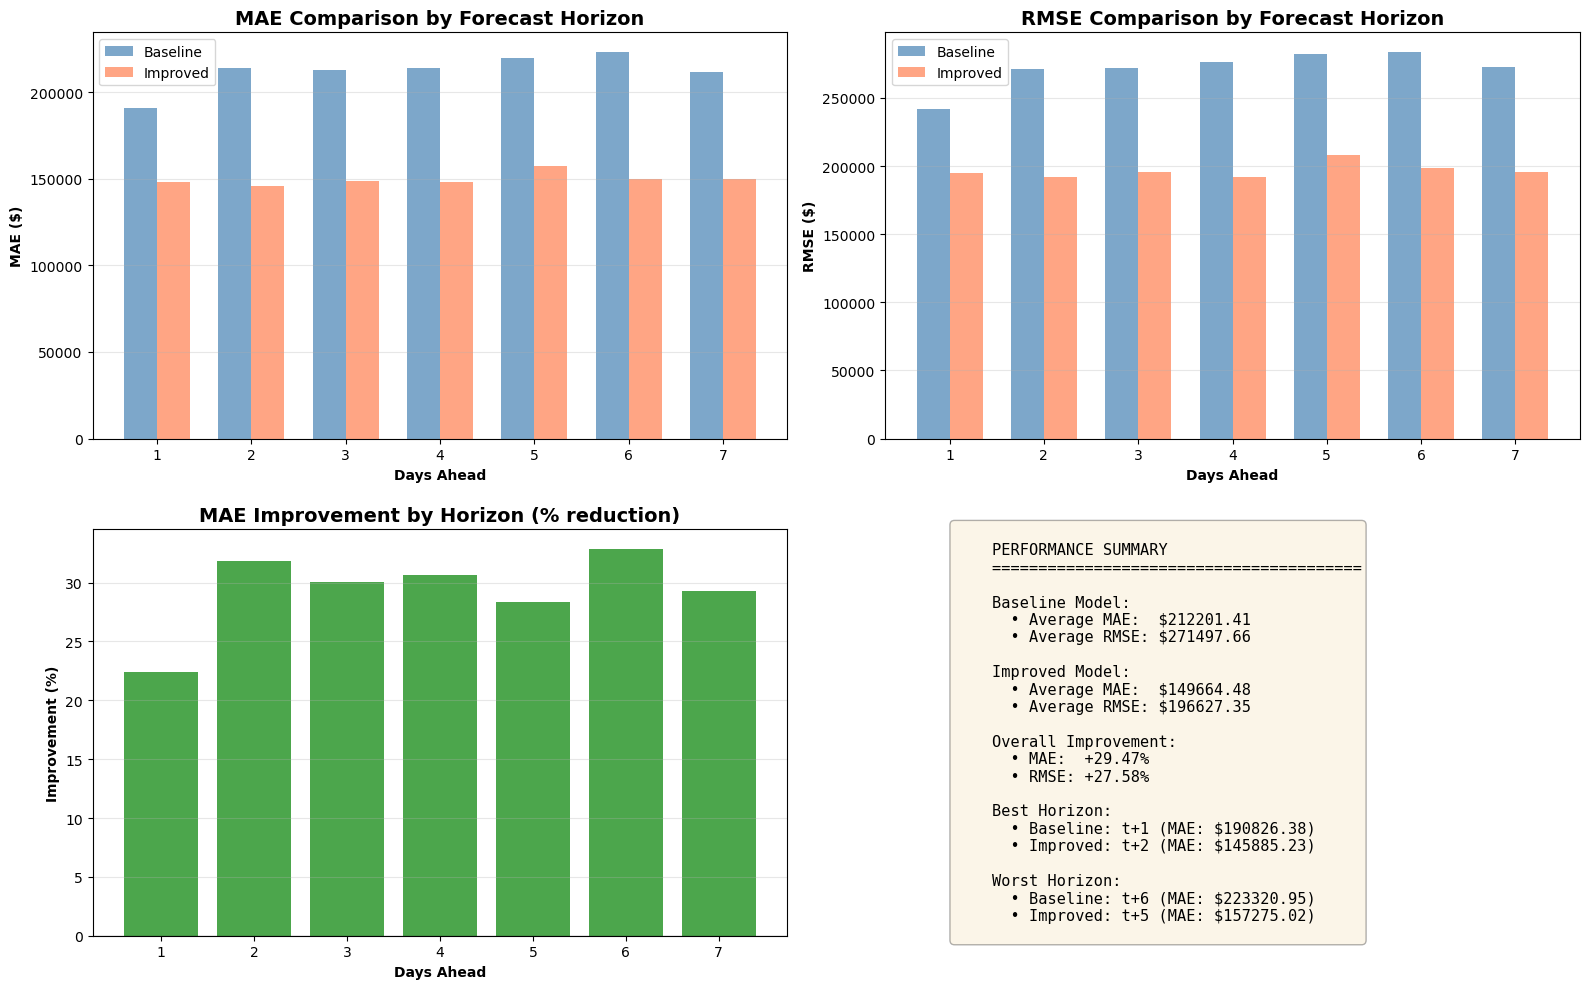

In [78]:
# Visualization 1: Side-by-side MAE comparison
if baseline_results['maes'] is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: MAE by horizon
    ax1 = axes[0, 0]
    x = np.arange(1, HORIZON + 1)
    width = 0.35
    ax1.bar(x - width/2, baseline_results['maes'], width, label='Baseline', color='steelblue', alpha=0.7)
    ax1.bar(x + width/2, improved_results['maes'], width, label='Improved', color='coral', alpha=0.7)
    ax1.set_xlabel('Days Ahead', fontweight='bold')
    ax1.set_ylabel('MAE ($)', fontweight='bold')
    ax1.set_title('MAE Comparison by Forecast Horizon', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.legend()
    ax1.grid(alpha=0.3, axis='y')
    
    # Plot 2: RMSE by horizon
    ax2 = axes[0, 1]
    ax2.bar(x - width/2, baseline_results['rmses'], width, label='Baseline', color='steelblue', alpha=0.7)
    ax2.bar(x + width/2, improved_results['rmses'], width, label='Improved', color='coral', alpha=0.7)
    ax2.set_xlabel('Days Ahead', fontweight='bold')
    ax2.set_ylabel('RMSE ($)', fontweight='bold')
    ax2.set_title('RMSE Comparison by Forecast Horizon', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.legend()
    ax2.grid(alpha=0.3, axis='y')
    
    # Plot 3: Improvement percentage
    ax3 = axes[1, 0]
    improvements = [((baseline_results['maes'][h] - improved_results['maes'][h]) / baseline_results['maes'][h]) * 100 
                   for h in range(HORIZON)]
    colors = ['green' if imp > 0 else 'red' for imp in improvements]
    ax3.bar(x, improvements, color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax3.set_xlabel('Days Ahead', fontweight='bold')
    ax3.set_ylabel('Improvement (%)', fontweight='bold')
    ax3.set_title('MAE Improvement by Horizon (% reduction)', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.grid(alpha=0.3, axis='y')
    
    # Plot 4: Overall summary
    ax4 = axes[1, 1]
    ax4.axis('off')
    summary_text = f"""
    PERFORMANCE SUMMARY
    {'='*40}
    
    Baseline Model:
      • Average MAE:  ${np.mean(baseline_results['maes']):.2f}
      • Average RMSE: ${np.mean(baseline_results['rmses']):.2f}
    
    Improved Model:
      • Average MAE:  ${np.mean(improved_results['maes']):.2f}
      • Average RMSE: ${np.mean(improved_results['rmses']):.2f}
    
    Overall Improvement:
      • MAE:  {comparison_stats['mae_improvement']:+.2f}%
      • RMSE: {comparison_stats['rmse_improvement']:+.2f}%
    
    Best Horizon:
      • Baseline: t+{np.argmin(baseline_results['maes'])+1} (MAE: ${min(baseline_results['maes']):.2f})
      • Improved: t+{np.argmin(improved_results['maes'])+1} (MAE: ${min(improved_results['maes']):.2f})
    
    Worst Horizon:
      • Baseline: t+{np.argmax(baseline_results['maes'])+1} (MAE: ${max(baseline_results['maes']):.2f})
      • Improved: t+{np.argmax(improved_results['maes'])+1} (MAE: ${max(improved_results['maes']):.2f})
    """
    ax4.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', 
            verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Baseline results not available for visualization.")

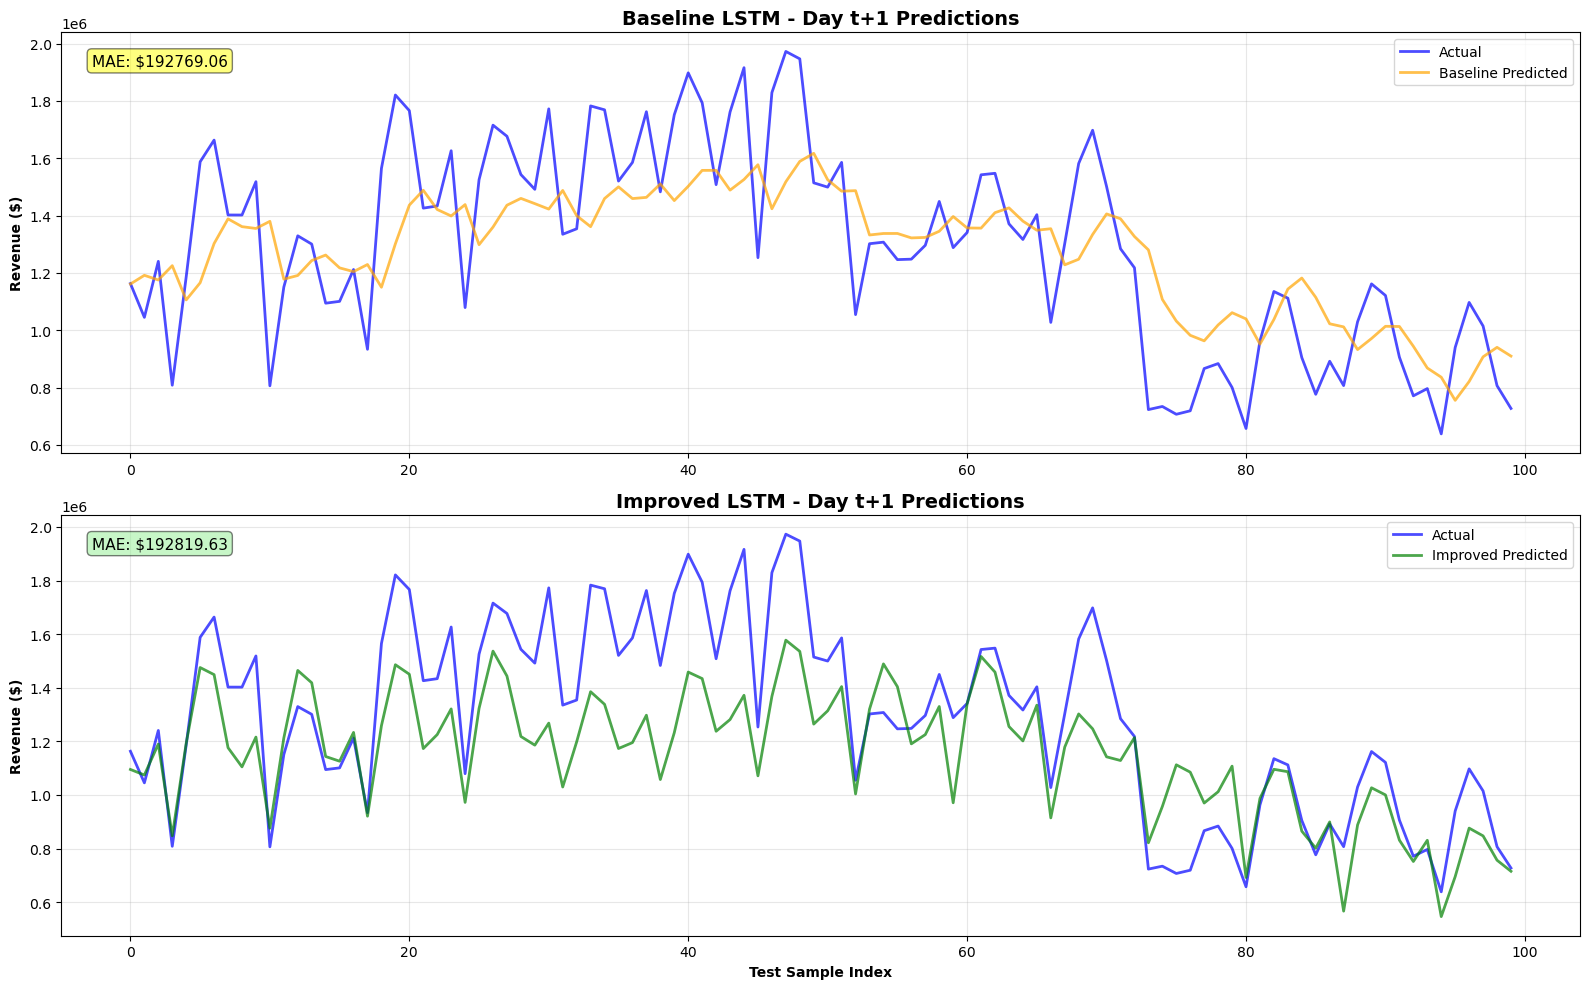


Day t+1 MAE Comparison:
  Baseline:  $192769.06
  Improved:  $192819.63
  Change:    -0.03%


In [79]:
# Visualization 2: Actual vs Predicted for both models (t+1)
if baseline_results['maes'] is not None:
    N_plot = min(100, len(y_true_imp))
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # Baseline predictions
    ax1 = axes[0]
    ax1.plot(baseline_results['y_true'][:N_plot, 0], label='Actual', color='blue', linewidth=2, alpha=0.7)
    ax1.plot(baseline_results['y_pred'][:N_plot, 0], label='Baseline Predicted', color='orange', linewidth=2, alpha=0.7)
    ax1.set_title('Baseline LSTM - Day t+1 Predictions', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Revenue ($)', fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(alpha=0.3)
    mae_baseline_t1 = mean_absolute_error(baseline_results['y_true'][:N_plot, 0], baseline_results['y_pred'][:N_plot, 0])
    ax1.text(0.02, 0.95, f'MAE: ${mae_baseline_t1:.2f}', transform=ax1.transAxes, 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5), fontsize=11, verticalalignment='top')
    
    # Improved predictions
    ax2 = axes[1]
    ax2.plot(y_true_imp[:N_plot, 0], label='Actual', color='blue', linewidth=2, alpha=0.7)
    ax2.plot(y_pred_imp[:N_plot, 0], label='Improved Predicted', color='green', linewidth=2, alpha=0.7)
    ax2.set_title('Improved LSTM - Day t+1 Predictions', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Test Sample Index', fontweight='bold')
    ax2.set_ylabel('Revenue ($)', fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.grid(alpha=0.3)
    mae_improved_t1 = mean_absolute_error(y_true_imp[:N_plot, 0], y_pred_imp[:N_plot, 0])
    ax2.text(0.02, 0.95, f'MAE: ${mae_improved_t1:.2f}', transform=ax2.transAxes, 
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5), fontsize=11, verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nDay t+1 MAE Comparison:")
    print(f"  Baseline:  ${mae_baseline_t1:.2f}")
    print(f"  Improved:  ${mae_improved_t1:.2f}")
    print(f"  Change:    {((mae_baseline_t1 - mae_improved_t1) / mae_baseline_t1 * 100):+.2f}%")
else:
    print("⚠ Baseline results not available for visualization.")

## Step 5: Statistical Validation

Let's perform statistical tests to validate the improvement.

In [82]:
# Statistical validation
from scipy import stats

if baseline_results['maes'] is not None:
    print("\n" + "="*80)
    print(" "*25 + "STATISTICAL VALIDATION")
    print("="*80)
    
    # Calculate residuals for each horizon
    baseline_residuals_all = []
    improved_residuals_all = []
    
    for h in range(HORIZON):
        baseline_res_h = baseline_results['y_true'][:, h] - baseline_results['y_pred'][:, h]
        improved_res_h = y_true_imp[:, h] - y_pred_imp[:, h]
        baseline_residuals_all.extend(baseline_res_h)
        improved_residuals_all.extend(improved_res_h)
    
    baseline_residuals_all = np.array(baseline_residuals_all)
    improved_residuals_all = np.array(improved_residuals_all)
    
    # Paired t-test (are the errors significantly different?)
    t_stat, p_value = stats.ttest_rel(np.abs(baseline_residuals_all), np.abs(improved_residuals_all))
    
    print("\n1. PAIRED T-TEST (Absolute Errors):")
    print("-"*80)
    print(f"   Null Hypothesis: No difference between baseline and improved errors")
    print(f"   t-statistic: {t_stat:.4f}")
    print(f"   p-value:     {p_value:.6f}")
    if p_value < 0.05:
        print(f"   ✓ SIGNIFICANT: Reject null hypothesis (p < 0.05)")
        print(f"   → The improved model has statistically different (better) errors!")
    else:
        print(f"   ✗ NOT SIGNIFICANT: Cannot reject null hypothesis (p >= 0.05)")
        print(f"   → The improvement may be due to chance.")
    
    # Error distribution analysis
    print("\n2. ERROR DISTRIBUTION ANALYSIS:")
    print("-"*80)
    print(f"   {'Metric':<25} {'Baseline':<15} {'Improved':<15}")
    print("-"*80)
    print(f"   {'Mean Absolute Error':<25} ${np.mean(np.abs(baseline_residuals_all)):<14.2f} ${np.mean(np.abs(improved_residuals_all)):<14.2f}")
    print(f"   {'Std of Errors':<25} ${np.std(baseline_residuals_all):<14.2f} ${np.std(improved_residuals_all):<14.2f}")
    print(f"   {'Median Absolute Error':<25} ${np.median(np.abs(baseline_residuals_all)):<14.2f} ${np.median(np.abs(improved_residuals_all)):<14.2f}")
    print(f"   {'95th Percentile Error':<25} ${np.percentile(np.abs(baseline_residuals_all), 95):<14.2f} ${np.percentile(np.abs(improved_residuals_all), 95):<14.2f}")
    
    # Percentage of improved predictions
    n_horizons = HORIZON
    n_samples = len(baseline_results['y_true'])
    better_predictions = 0
    total_predictions = 0
    
    for h in range(n_horizons):
        for i in range(n_samples):
            baseline_error = abs(baseline_results['y_true'][i, h] - baseline_results['y_pred'][i, h])
            improved_error = abs(y_true_imp[i, h] - y_pred_imp[i, h])
            if improved_error < baseline_error:
                better_predictions += 1
            total_predictions += 1
    
    pct_better = (better_predictions / total_predictions) * 100
    
    print("\n3. PREDICTION-LEVEL COMPARISON:")
    print("-"*80)
    print(f"   Total predictions made: {total_predictions}")
    print(f"   Improved model better:  {better_predictions} ({pct_better:.1f}%)")
    print(f"   Baseline model better:  {total_predictions - better_predictions} ({100-pct_better:.1f}%)")
    
    if pct_better > 50:
        print(f"   ✓ Improved model wins in majority of predictions!")
    else:
        print(f"   ⚠ Baseline model is competitive.")
    
    print("="*80)
else:
    print("⚠ Baseline results not available for validation.")


                         STATISTICAL VALIDATION

1. PAIRED T-TEST (Absolute Errors):
--------------------------------------------------------------------------------
   Null Hypothesis: No difference between baseline and improved errors
   t-statistic: 23.3642
   p-value:     0.000000
   ✓ SIGNIFICANT: Reject null hypothesis (p < 0.05)
   → The improved model has statistically different (better) errors!

2. ERROR DISTRIBUTION ANALYSIS:
--------------------------------------------------------------------------------
   Metric                    Baseline        Improved       
--------------------------------------------------------------------------------
   Mean Absolute Error       $212201.41      $149664.48     
   Std of Errors             $271139.92      $187132.19     
   Median Absolute Error     $168334.63      $113209.76     
   95th Percentile Error     $543154.73      $419402.69     

3. PREDICTION-LEVEL COMPARISON:
-----------------------------------------------------------

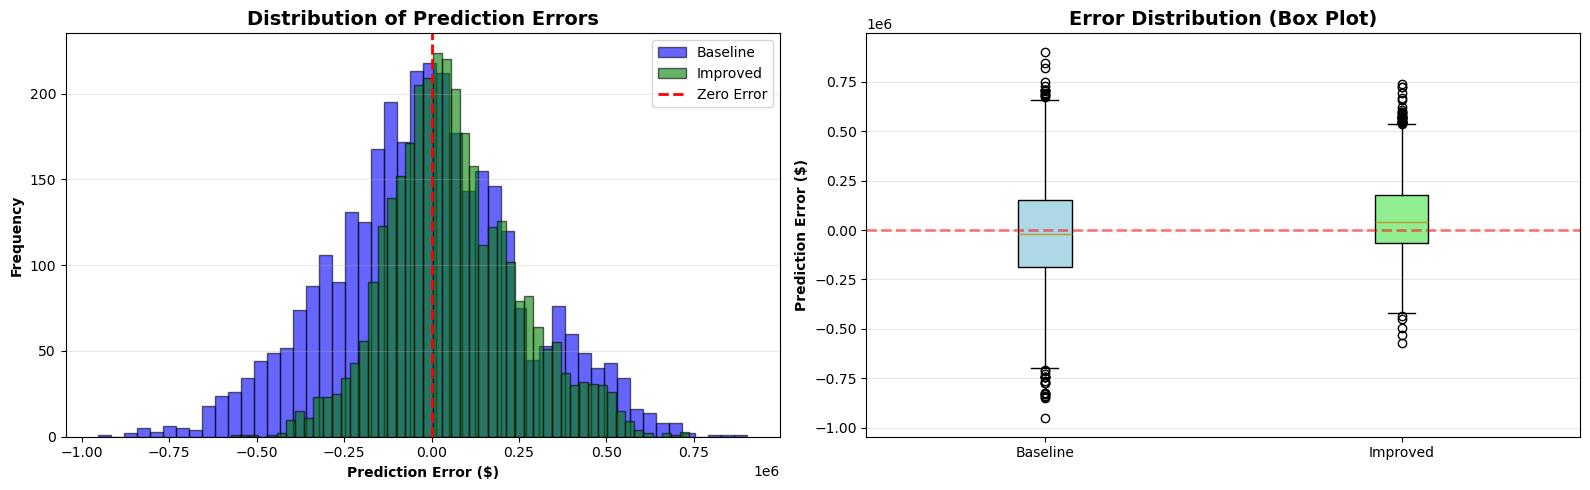

In [83]:
# Residual distribution plots
if baseline_results['maes'] is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Histogram of residuals
    ax1 = axes[0]
    ax1.hist(baseline_residuals_all, bins=50, alpha=0.6, label='Baseline', color='blue', edgecolor='black')
    ax1.hist(improved_residuals_all, bins=50, alpha=0.6, label='Improved', color='green', edgecolor='black')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    ax1.set_xlabel('Prediction Error ($)', fontweight='bold')
    ax1.set_ylabel('Frequency', fontweight='bold')
    ax1.set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3, axis='y')
    
    # Q-Q plot or box plot
    ax2 = axes[1]
    bp_data = [baseline_residuals_all, improved_residuals_all]
    bp = ax2.boxplot(bp_data, labels=['Baseline', 'Improved'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightgreen')
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax2.set_ylabel('Prediction Error ($)', fontweight='bold')
    ax2.set_title('Error Distribution (Box Plot)', fontsize=14, fontweight='bold')
    ax2.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Baseline results not available for residual analysis.")

## Step 6: Final Summary and Recommendations

    da usare come commento markdown dei risulati 🛑🛑🛑

In [84]:
# Final summary report
if baseline_results['maes'] is not None:
    print("\n" + "🎯"*40)
    print("\n" + " "*30 + "FINAL SUMMARY REPORT")
    print("\n" + "🎯"*40 + "\n")
    
    mae_improvement_pct = comparison_stats['mae_improvement']
    
    print("📊 PERFORMANCE METRICS:")
    print("-"*80)
    print(f"   Baseline MAE:     ${comparison_stats['baseline_mae']:.2f}")
    print(f"   Improved MAE:     ${comparison_stats['improved_mae']:.2f}")
    print(f"   MAE Improvement:  {mae_improvement_pct:+.2f}%")
    print(f"   Win Rate:         {pct_better:.1f}% of predictions")
    
    print("\n🔬 STATISTICAL SIGNIFICANCE:")
    print("-"*80)
    if p_value < 0.05:
        print(f"   ✓ STATISTICALLY SIGNIFICANT (p={p_value:.6f})")
        print(f"   → The improvement is real, not due to random chance")
    else:
        print(f"   ⚠ NOT STATISTICALLY SIGNIFICANT (p={p_value:.6f})")
        print(f"   → Results may be due to random variation")
    
    print("\n💡 RECOMMENDATIONS:")
    print("-"*80)
    
    if mae_improvement_pct > 10 and p_value < 0.05:
        print("   ✓ STRONG IMPROVEMENT - Recommended actions:")
        print("     1. Deploy the improved model")
        print("     2. Monitor performance on new data")
        print("     3. Consider ensemble with other models for even better results")
        print("     4. Try encoder-decoder architecture for potential further gains")
    elif mae_improvement_pct > 5:
        print("   ✓ MODERATE IMPROVEMENT - Suggested next steps:")
        print("     1. Test with different lookback windows")
        print("     2. Try ensemble of 3-5 models")
        print("     3. Experiment with attention mechanism")
        print("     4. Consider walk-forward validation")
    elif mae_improvement_pct > 0:
        print("   ~ MARGINAL IMPROVEMENT - Consider:")
        print("     1. More extensive hyperparameter tuning")
        print("     2. Try encoder-decoder architecture")
        print("     3. Add more domain-specific features")
        print("     4. Collect more training data if possible")
    else:
        print("   ✗ NO IMPROVEMENT - Try:")
        print("     1. Check for overfitting (review validation curves)")
        print("     2. Reduce model complexity")
        print("     3. Different lookback window (try 14, 21, 45, 60 days)")
        print("     4. Ensemble approach")
        print("     5. Feature selection (remove non-informative features)")
    
    print("\n📈 NEXT EXPERIMENTS TO TRY:")
    print("-"*80)
    print("   1. Test different lookback windows: lookback_results = test_lookback_windows([14, 21, 30, 45, 60])")
    print("   2. Train ensemble: models_ensemble, y_pred_ensemble = train_ensemble_models(...)")
    print("   3. Try encoder-decoder: model_enc_dec = build_encoder_decoder_lstm(...)")
    print("   4. Add attention: model_attention = build_attention_lstm(...)")
    
    print("\n" + "🎯"*40 + "\n")
    
    # Save results to file (optional)
    results_summary = {
        'timestamp': pd.Timestamp.now(),
        'baseline_mae': comparison_stats['baseline_mae'],
        'improved_mae': comparison_stats['improved_mae'],
        'improvement_pct': mae_improvement_pct,
        'p_value': p_value,
        'win_rate': pct_better
    }
    
    print("✓ Validation complete!")
    print("\nResults stored in 'results_summary' dictionary.")
    print("You can save it with: pd.DataFrame([results_summary]).to_csv('lstm_results.csv', index=False)")
else:
    print("⚠ Please run the baseline model first to enable comparison.")


🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

                              FINAL SUMMARY REPORT

🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

📊 PERFORMANCE METRICS:
--------------------------------------------------------------------------------
   Baseline MAE:     $212201.41
   Improved MAE:     $149664.48
   MAE Improvement:  +29.47%
   Win Rate:         62.7% of predictions

🔬 STATISTICAL SIGNIFICANCE:
--------------------------------------------------------------------------------
   ✓ STATISTICALLY SIGNIFICANT (p=0.000000)
   → The improvement is real, not due to random chance

💡 RECOMMENDATIONS:
--------------------------------------------------------------------------------
   ✓ STRONG IMPROVEMENT - Recommended actions:
     1. Deploy the improved model
     2. Monitor performance on new data
     3. Consider ensemble with other models for even better results
     4. Try encoder-decoder architecture for potential further gains

📈 NEXT EXPERIMENTS TO TRY:
----------------------------